# Mini-GNN Segment Embedder — Cosine Similarity Analysis

Inspect the trained `SegmentGNN` by computing cosine similarity distributions for
**true segment pairs** (same particle) vs **negative pairs** (different particles).

**Part 1** — GNN-inferred CC segments (exactly as used at inference time)  
**Part 2** — Ground truth segments (`hit_segment_id`)  
**Part 3** — GT physics arcs (ingoing/outgoing split at radial turnaround)

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch_geometric.data import Batch, Data
from tqdm import tqdm

SCRIPT_DIR    = Path().resolve()
PIPELINE_ROOT = SCRIPT_DIR.parent
WORKSPACE_ROOT = PIPELINE_ROOT.parent

sys.path.insert(0, str(WORKSPACE_ROOT / 'acorn'))
sys.path.insert(0, str(PIPELINE_ROOT))


from low_pt_custom_utils.track_evaluation_utils import PDG_TO_SPECIES
from low_pt_custom_utils.track_evaluation_utils import SPECIES_COLORS, SPECIES_MARKERS

from low_pt_custom_utils.mini_gnn_segment_embedding import (
    load_segment_gnn,
    segment_to_pyg,
    get_segment_particle_id,
)
from low_pt_custom_utils.segment_matching import (
    extract_segments_from_cc,
    extract_segments_from_ground_truth,
)



/data/alice/bkuipers/miniconda3/envs/acorn/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data/alice/bkuipers/miniconda3/envs/acorn/lib/python3.10/site-packages/lightning_fabric/__init__.py:40: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


In [2]:
MODEL_PATH = (
    PIPELINE_ROOT
    / 'data/track_building/mini_GNN_checkpoints'
    / 'mini_gnn_segment_embedder_val_loss=1.6115.pt'
)

#mini_gnn_segment_embedder_val_loss=1.2621.pt'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model  = load_segment_gnn(str(MODEL_PATH), device=device)

ckpt = torch.load(str(MODEL_PATH), map_location='cpu', weights_only=True)
print(f'Model: {MODEL_PATH.name}')
print(f'  hidden_dim={ckpt["hidden_dim"]}, emb_dim={ckpt["emb_dim"]}, '
      f'n_layers={ckpt["n_layers"]}, dropout={ckpt["dropout"]}')
print(f'  node_scales={ckpt["node_scales"]}')
print(f'  device={device}')

Model: mini_gnn_segment_embedder_val_loss=1.6115.pt
  hidden_dim=128, emb_dim=16, n_layers=4, dropout=0.001
  node_scales=[1000, 1000, 500, 1000]
  device=cpu


/data/alice/bkuipers/miniconda3/envs/acorn/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


In [3]:
# --- Configuration (matches gnn_segment_matching.yaml) ---
SCORE_CUT         = 0.85    # GNN edge score threshold for CC cluster extraction
OUTER_R_THRESHOLD = 1000.0   # mm — outermost hit >= this → complete track, excluded from matching

DATA_DIR    = PIPELINE_ROOT / 'data' / 'gnn_stage' / 'valset'
event_paths = sorted(DATA_DIR.glob('*.pyg'))
print(f'Events:            {len(event_paths)}')
print(f'Score cut:         {SCORE_CUT}')
print(f'outer_r threshold: {OUTER_R_THRESHOLD} mm')

Events:            900
Score cut:         0.85
outer_r threshold: 1000.0 mm


In [4]:
# --- Shared helpers ---

def embed_segments(segments, graph, model, device):
    """Return (embeddings, particle_ids) for a list of SegmentInfo."""
    node_scales = tuple(model.node_scales)
    seg_graphs  = [segment_to_pyg(seg, graph, node_scales=node_scales) for seg in segments]
    batch_data  = Batch.from_data_list(seg_graphs).to(device)
    with torch.no_grad():
        embs = model(batch_data.x, batch_data.edge_index, batch_data.batch)
    embs = embs.cpu()
    pids = np.array([get_segment_particle_id(seg, graph) for seg in segments])
    return embs, pids


def true_pair_cosine_sims(embs, pids):
    """Cosine similarities for all same-particle segment pairs (pid > 0)."""
    sim_matrix = (embs @ embs.T).numpy()
    sims = []
    n = len(pids)
    for i in range(n):
        if pids[i] == 0:
            continue
        for j in range(i + 1, n):
            if pids[j] == pids[i]:
                sims.append(sim_matrix[i, j])
    return np.array(sims)


def neg_pair_cosine_sims(embs, pids):
    """Cosine similarities for all different-particle segment pairs."""
    sim_matrix = (embs @ embs.T).numpy()
    sims = []
    n = len(pids)
    for i in range(n):
        if pids[i] == 0:
            continue
        for j in range(i + 1, n):
            if pids[j] != pids[i] and pids[j] != 0:
                sims.append(sim_matrix[i, j])
    return np.array(sims)


bins = np.linspace(-1, 1, 80)
print('Helpers defined')

Helpers defined


---
## Part 1 — GNN-inferred CC segments

Segments from Connected Components on GNN edge scores (`score > SCORE_CUT`).
Complete-track segments (`outer_r >= OUTER_R_THRESHOLD`) are excluded — identical to inference.

In [5]:
# --- Part 1: all events, CC segments ---

cc_true_sims = []
cc_neg_sims  = []

for path in tqdm(event_paths, desc='CC segments'):
    graph = torch.load(path, map_location='cpu', weights_only=False)

    segments = extract_segments_from_cc(graph, SCORE_CUT)
    segments = [s for s in segments if s.outer_r < OUTER_R_THRESHOLD]
    if len(segments) < 2:
        continue

    embs, pids = embed_segments(segments, graph, model, device)
    cc_true_sims.extend(true_pair_cosine_sims(embs, pids))
    cc_neg_sims.extend(neg_pair_cosine_sims(embs, pids))

cc_true_sims = np.array(cc_true_sims)
cc_neg_sims  = np.array(cc_neg_sims)

print(f'True pairs:     {len(cc_true_sims):>7,}')
print(f'Negative pairs: {len(cc_neg_sims):>7,}')
if len(cc_true_sims):
    print(f'\nTrue   mean={cc_true_sims.mean():.4f}  median={np.median(cc_true_sims):.4f}  std={cc_true_sims.std():.4f}')
if len(cc_neg_sims):
    print(f'Neg    mean={cc_neg_sims.mean():.4f}  median={np.median(cc_neg_sims):.4f}  std={cc_neg_sims.std():.4f}')

CC segments: 100%|██████████| 900/900 [02:55<00:00,  5.14it/s]


True pairs:      41,724
Negative pairs: 4,165,430

True   mean=0.9194  median=0.9720  std=0.1286
Neg    mean=0.0030  median=0.0047  std=0.2515


Saved: /data/alice/bkuipers/low_pt_gnn_pipeline/data/visuals/cosine_sim_cc_segments_global.pdf


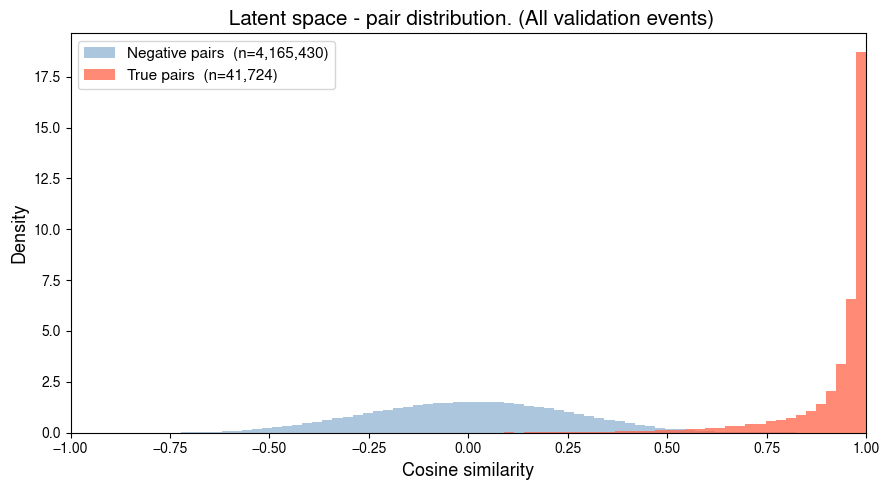

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
if len(cc_neg_sims):
    ax.hist(cc_neg_sims,  bins=bins, alpha=0.45, color='steelblue',
            label=f'Negative pairs  (n={len(cc_neg_sims):,})', density=True)
if len(cc_true_sims):
    ax.hist(cc_true_sims, bins=bins, alpha=0.75, color='tomato',
            label=f'True pairs  (n={len(cc_true_sims):,})', density=True)

ax.set_xlabel('Cosine similarity', fontsize=13)
ax.set_ylabel('Density', fontsize=13)
ax.set_title(f' Latent space - pair distribution. (All validation events)', fontsize=15)
ax.legend(fontsize=11)
ax.set_xlim(-1, 1)
fig.tight_layout()

out_path = PIPELINE_ROOT / 'data' / 'visuals' / 'cosine_sim_cc_segments_global.pdf'
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, format='pdf', bbox_inches='tight')
print(f'Saved: {out_path}')

plt.show()

In [7]:
# from collections import defaultdict

# # ── Re-run CC embedding, collecting true-pair sims labelled by particle species ─
# cc_true_sims_species = defaultdict(list)

# for path in tqdm(event_paths, desc='CC segments (per species)'):
#     graph = torch.load(path, map_location='cpu', weights_only=False)

#     # Build pid → species map
#     pid_species = {}
#     if hasattr(graph, 'track_edges') and hasattr(graph, 'track_particle_type'):
#         edge_pids  = graph.hit_particle_id[graph.track_edges[0, :]].numpy()
#         edge_ptype = graph.track_particle_type.numpy()
#         for pid, ptype in zip(edge_pids, edge_ptype):
#             pid = int(pid)
#             if pid > 0 and pid not in pid_species:
#                 pid_species[pid] = PDG_TO_SPECIES.get(int(ptype), 'Other')

#     segments = extract_segments_from_cc(graph, SCORE_CUT)
#     segments = [s for s in segments if s.outer_r < OUTER_R_THRESHOLD]
#     if len(segments) < 2:
#         continue

#     embs, pids = embed_segments(segments, graph, model, device)
#     sim_matrix = (embs @ embs.T).numpy()

#     n = len(pids)
#     for i in range(n):
#         pid_i = int(pids[i])
#         if pid_i == 0:
#             continue
#         sp = pid_species.get(pid_i, 'Other')
#         for j in range(i + 1, n):
#             if int(pids[j]) == pid_i:
#                 cc_true_sims_species[sp].append(sim_matrix[i, j])

# for sp, sims in sorted(cc_true_sims_species.items()):
#     print(f'  {sp:12s}: {len(sims):>6,} true pairs  '
#           f'mean={np.mean(sims):.3f}  std={np.std(sims):.3f}')

In [8]:
# species_order = [s for s in ['Muon', 'Pion', 'Electron', 'Proton', 'Kaon']
#                  if s in cc_true_sims_species]
# ncols = 2
# nrows = (len(species_order) + 1) // 2

# fig, axes = plt.subplots(nrows, ncols, figsize=(11, 4.5 * nrows))
# axes = axes.flatten()

# for idx, species in enumerate(species_order):
#     ax    = axes[idx]
#     sims  = np.array(cc_true_sims_species[species])
#     color = SPECIES_COLORS.get(species, 'tomato')

#     ax.hist(cc_neg_sims, bins=bins, alpha=0.40, color='steelblue', density=True,
#             label=f'Negative (all,  n={len(cc_neg_sims):,})')
#     ax.hist(sims,        bins=bins, alpha=0.75, color=color,       density=True,
#             label=f'True — {species}  (n={len(sims):,})')


#     ax.set_xlabel('Cosine similarity', fontsize=12)
#     ax.set_ylabel('Density', fontsize=12)
#     ax.set_title(species, fontsize=13, color=color, fontweight='bold')
#     ax.legend(fontsize=9)
#     ax.set_xlim(-1, 1)

# for idx in range(len(species_order), len(axes)):
#     axes[idx].set_visible(False)

# fig.suptitle(
#     f'Mini-GNN cosine similarity by species — CC segments  '
#     f'(score>{SCORE_CUT}, outer_r<{OUTER_R_THRESHOLD:.0f}mm)',
#     fontsize=13,
# )
# fig.tight_layout()
# plt.show()

In [9]:
# --- Part 1: single event ---
EVENT_INDEX = 0

graph_single = torch.load(event_paths[EVENT_INDEX], map_location='cpu', weights_only=False)
event_id = graph_single.event_id
if isinstance(event_id, list):
    event_id = event_id[0]
print(f'Event: {event_id}  ({event_paths[EVENT_INDEX].name})')
print(f'  Hits: {graph_single.hit_x.size(0)}')

segs_cc = extract_segments_from_cc(graph_single, SCORE_CUT)
n_complete_cc = sum(1 for s in segs_cc if s.outer_r >= OUTER_R_THRESHOLD)
segs_cc = [s for s in segs_cc if s.outer_r < OUTER_R_THRESHOLD]

embs_single, pids_single = embed_segments(segs_cc, graph_single, model, device)
unique_pids, counts = np.unique(pids_single[pids_single > 0], return_counts=True)

true_sims_single = true_pair_cosine_sims(embs_single, pids_single)
neg_sims_single  = neg_pair_cosine_sims(embs_single, pids_single)

print(f'  CC segments (all):    {len(segs_cc) + n_complete_cc}')
print(f'  Complete (excluded):  {n_complete_cc}  (outer_r >= {OUTER_R_THRESHOLD:.0f} mm)')
print(f'  Segments remaining:   {len(segs_cc)}')
print(f'  Multi-seg particles:  {(counts > 1).sum()}')
print(f'  True pairs:           {len(true_sims_single)}')
print(f'  Negative pairs:       {len(neg_sims_single)}')
if len(true_sims_single):
    print(f'  True   mean={true_sims_single.mean():.4f}  min={true_sims_single.min():.4f}  max={true_sims_single.max():.4f}')

Event: 000100079  (event000100079.pyg)
  Hits: 1063
  CC segments (all):    134
  Complete (excluded):  34  (outer_r >= 1000 mm)
  Segments remaining:   100
  Multi-seg particles:  43
  True pairs:           43
  Negative pairs:       4907
  True   mean=0.9287  min=0.5952  max=0.9973


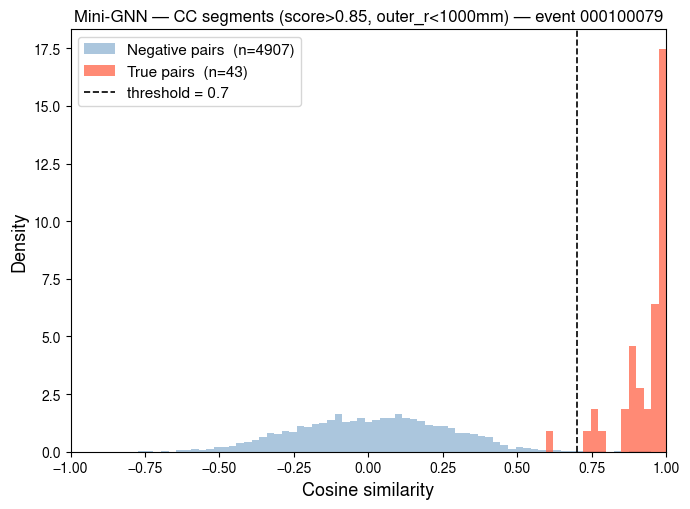

In [10]:
fig, ax = plt.subplots(figsize=(7, 5.2))
if len(neg_sims_single):
    ax.hist(neg_sims_single,  bins=bins, alpha=0.45, color='steelblue',
            label=f'Negative pairs  (n={len(neg_sims_single)})', density=True)
if len(true_sims_single):
    ax.hist(true_sims_single, bins=bins, alpha=0.75, color='tomato',
            label=f'True pairs  (n={len(true_sims_single)})', density=True)
ax.axvline(0.7, color='black', linestyle='--', linewidth=1.2, label='threshold = 0.7')
ax.set_xlabel('Cosine similarity', fontsize=13)
ax.set_ylabel('Density', fontsize=13)
ax.set_title(f'Mini-GNN — CC segments (score>{SCORE_CUT}, outer_r<{OUTER_R_THRESHOLD:.0f}mm) — event {event_id}', fontsize=12)
ax.legend(fontsize=11)
ax.set_xlim(-1, 1)
fig.tight_layout()
plt.show()

In [11]:
# --- Per-particle breakdown (single event, CC segments) ---
print(f'Per-particle true pair cosine similarities (event {event_id}):\n')
print(f'  {"particle_id":>15}  {"n_segs":>6}  {"cos_sim":>10}')
print('  ' + '-' * 40)

sim_matrix_single = (embs_single @ embs_single.T).numpy()
for pid in unique_pids:
    seg_idxs = np.where(pids_single == pid)[0]
    if len(seg_idxs) < 2:
        continue
    i, j = seg_idxs[0], seg_idxs[1]
    s = sim_matrix_single[i, j]

    print(f'  {pid:>15}  {len(seg_idxs):>6} ')

Per-particle true pair cosine similarities (event 000100079):

      particle_id  n_segs     cos_sim
  ----------------------------------------
  4503599677702144       2 
  4503599711256576       2 
  4503599778365440       2 
  4503599828697088       2 
  4503599912583168       2 
  4503599946137600       2 
  4503599979692032       2 
  4503599996469248       2 
  4503600013246464       2 
  9007199288295424       2 
  9007199305072640       2 
  9007199388958720       2 
  9007199405735936       2 
  9007199422513152       2 
  9007199456067584       2 
  9007199506399232       2 
  9007199523176448       2 
  9007199573508096       2 
  9007199590285312       2 
  9007199623839744       2 
  9007199640616960       2 
  9007199657394176       2 
  9007199674171392       2 
  13510798898888704       2 
  13510798915665920       2 
  13510798932443136       2 
  13510798949220352       2 
  13510798965997568       2 
  13510798982774784       2 
  13510799033106432       2 
  1351079

In [12]:
# --- Top highest-cos-sim NEGATIVE pairs (single event) ---
TOP_N = 20

seg_count = {}
for pid in pids_single:
    if pid > 0:
        seg_count[int(pid)] = seg_count.get(int(pid), 0) + 1

neg_pair_list = []
n_seg = len(pids_single)
for i in range(n_seg):
    if pids_single[i] == 0:
        continue
    for j in range(i + 1, n_seg):
        if pids_single[j] != pids_single[i] and pids_single[j] != 0:
            neg_pair_list.append((float(sim_matrix_single[i, j]),
                                  int(pids_single[i]), int(pids_single[j])))

neg_pair_list.sort(reverse=True)

print(f'Top {TOP_N} highest cos-sim NEGATIVE pairs (event {event_id}):\n')
print(f'  {"cos_sim":>8}  {"pid_i":>20}  {"n_segs_i":>8}  {"pid_j":>20}  {"n_segs_j":>8}')
print('  ' + '-' * 72)
for s, pid_i, pid_j in neg_pair_list[:TOP_N]:
    ni = seg_count.get(pid_i, 0)
    nj = seg_count.get(pid_j, 0)
    flag = '  <- multi-seg!' if ni > 2 or nj > 2 else ''
    print(f'  {s:>8.4f}  {pid_i:>20}  {ni:>8}  {pid_j:>20}  {nj:>8}{flag}')

Top 20 highest cos-sim NEGATIVE pairs (event 000100079):

   cos_sim                 pid_i  n_segs_i                 pid_j  n_segs_j
  ------------------------------------------------------------------------
    0.9351      4503599728033792         1      9007199556730880         1
    0.9341     13510799234433024         2     13510799133769728         2
    0.9142      9007199388958720         2      4503599912583168         2
    0.9071      4503599912583168         2      9007199456067584         2
    0.8971      9007199439290368         1     18014398828249088         1
    0.8785      4503599912583168         2      9007199388958720         2
    0.8596      4503599912583168         2      9007199388958720         2
    0.8464     13510799234433024         2     13510799133769728         2
    0.8419      9007199623839744         2      9007199405735936         2
    0.8351      4503599912583168         2      9007199456067584         2
    0.8243     18014398660476928         2

---
## Part 2 — Ground truth segments 



In [13]:
# # --- Part 2: all events, GT segments ---

# gt_true_sims = []
# gt_neg_sims  = []
# skipped_gt   = 0

# for path in tqdm(event_paths, desc='GT segments'):
#     graph = torch.load(path, map_location='cpu', weights_only=False)

#     if not hasattr(graph, 'hit_segment_id'):
#         skipped_gt += 1
#         continue

#     segments = extract_segments_from_ground_truth(graph)
#     segments = [s for s in segments if s.outer_r < OUTER_R_THRESHOLD]
#     if len(segments) < 2:
#         continue

#     embs, pids = embed_segments(segments, graph, model, device)
#     gt_true_sims.extend(true_pair_cosine_sims(embs, pids))
#     gt_neg_sims.extend(neg_pair_cosine_sims(embs, pids))

# gt_true_sims = np.array(gt_true_sims)
# gt_neg_sims  = np.array(gt_neg_sims)

# print(f'True pairs:     {len(gt_true_sims):>7,}')
# print(f'Negative pairs: {len(gt_neg_sims):>7,}')
# if skipped_gt:
#     print(f'Events skipped (no hit_segment_id): {skipped_gt}')
# if len(gt_true_sims):
#     print(f'\nTrue   mean={gt_true_sims.mean():.4f}  median={np.median(gt_true_sims):.4f}  std={gt_true_sims.std():.4f}')
# if len(gt_neg_sims):
#     print(f'Neg    mean={gt_neg_sims.mean():.4f}  median={np.median(gt_neg_sims):.4f}  std={gt_neg_sims.std():.4f}')

In [14]:
# fig, ax = plt.subplots(figsize=(9, 5))
# if len(gt_neg_sims):
#     ax.hist(gt_neg_sims,  bins=bins, alpha=0.45, color='steelblue',
#             label=f'Negative pairs  (n={len(gt_neg_sims):,})', density=True)
# if len(gt_true_sims):
#     ax.hist(gt_true_sims, bins=bins, alpha=0.75, color='tomato',
#             label=f'True pairs  (n={len(gt_true_sims):,})', density=True)
# ax.axvline(0.7, color='black', linestyle='--', linewidth=1.2, label='threshold = 0.7')
# ax.set_xlabel('Cosine similarity', fontsize=13)
# ax.set_ylabel('Density', fontsize=13)
# ax.set_title(f'Mini-GNN — GT segments (outer_r<{OUTER_R_THRESHOLD:.0f}mm) — all events', fontsize=12)
# ax.legend(fontsize=11)
# ax.set_xlim(-1, 1)
# fig.tight_layout()
# plt.show()

---
## Part 3 — KDE Fit & Optimal Decision Boundary

The true-pair distribution is left-skewed with a hard pile-up near 1.0 — not Gaussian.
A **kernel density estimate (KDE)** is used instead to capture the actual shape of both
distributions, then the **Bayes-optimal decision boundary** is found where the weighted densities cross:

$$w_\text{true} \cdot \hat{p}(x\,|\,\text{true}) = w_\text{neg} \cdot \hat{p}(x\,|\,\text{neg})$$

Fitting is done on a 50 K subsample — KDE estimates are stable well below 4 M points.

In [15]:
from scipy.stats import gaussian_kde
from scipy.optimize import brentq

# ── Subsample for KDE (stable at 50 K, much less than 4 M) ───────────────────
MAX_KDE = 5000000
rng = np.random.default_rng(42)

true_kde_data = rng.choice(cc_true_sims, min(MAX_KDE, len(cc_true_sims)), replace=False)
neg_kde_data  = rng.choice(cc_neg_sims,  min(MAX_KDE, len(cc_neg_sims)),  replace=False)

# Scott's rule bandwidth (default, works well for unimodal distributions)
kde_true = gaussian_kde(true_kde_data, bw_method='scott')
kde_neg  = gaussian_kde(neg_kde_data,  bw_method='scott')

# Class priors from full dataset counts
w_true = len(cc_true_sims) / (len(cc_true_sims) + len(cc_neg_sims))
w_neg  = 1 - w_true

print(f"KDE fitted on {len(true_kde_data):,} true  /  {len(neg_kde_data):,} neg samples")
print(f"  True bandwidth (Scott): {kde_true.factor:.4f}")
print(f"  Neg  bandwidth (Scott): {kde_neg.factor:.4f}")
print(f"  w_true = {w_true:.5f},  w_neg = {w_neg:.5f}")

# ── Optimal Bayes boundary ────────────────────────────────────────────────────
# Find where w_true * p(x|true) = w_neg * p(x|neg)
f = lambda x: float(w_true * kde_true(x) - w_neg * kde_neg(x))
boundary_trunc = brentq(f, -0.5, 0.999)
print(f"\nOptimal Bayes boundary (KDE): cos_sim = {boundary_trunc:.4f}")

KDE fitted on 41,724 true  /  4,165,430 neg samples
  True bandwidth (Scott): 0.1191
  Neg  bandwidth (Scott): 0.0474
  w_true = 0.00992,  w_neg = 0.99008


/tmp/ipykernel_2553081/3860572461.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f = lambda x: float(w_true * kde_true(x) - w_neg * kde_neg(x))



Optimal Bayes boundary (KDE): cos_sim = 0.8501


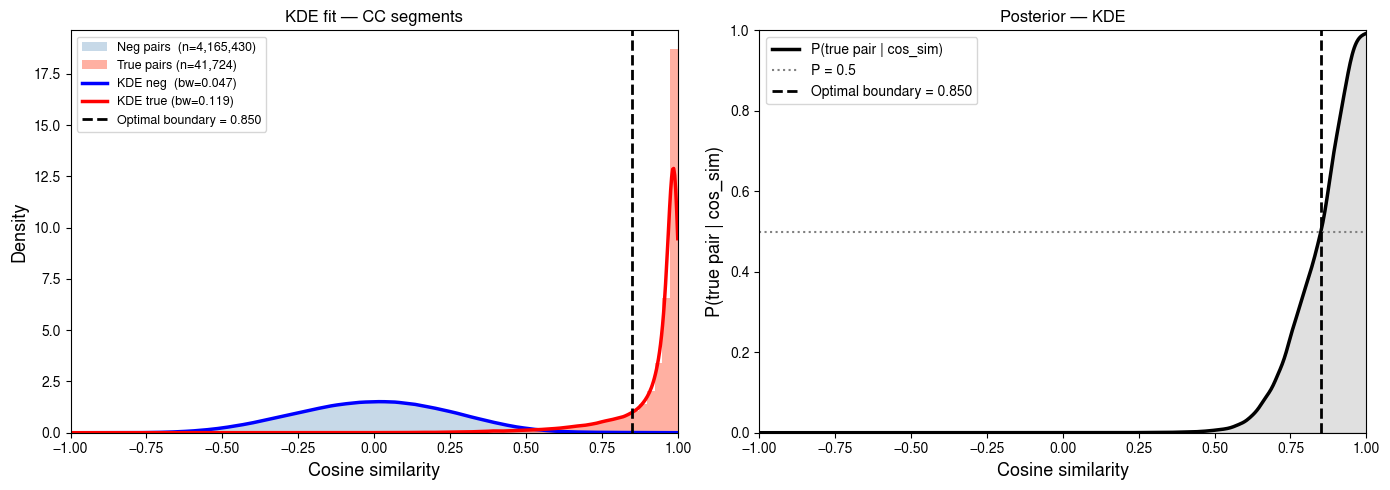

In [16]:
x_plot = np.linspace(-1, 1, 600)

curve_true = kde_true(x_plot)
curve_neg  = kde_neg(x_plot)

pdf_true   = w_true * curve_true
pdf_neg    = w_neg  * curve_neg
posterior  = pdf_true / (pdf_true + pdf_neg + 1e-300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: KDE overlaid on histograms ─────────────────────────────────────────
ax = axes[0]
ax.hist(cc_neg_sims,  bins=bins, alpha=0.30, color='steelblue', density=True,
        label=f'Neg pairs  (n={len(cc_neg_sims):,})')
ax.hist(cc_true_sims, bins=bins, alpha=0.50, color='tomato',    density=True,
        label=f'True pairs (n={len(cc_true_sims):,})')
ax.plot(x_plot, curve_neg,  'b-', lw=2.5,
        label=f'KDE neg  (bw={kde_neg.factor:.3f})')
ax.plot(x_plot, curve_true, 'r-', lw=2.5,
        label=f'KDE true (bw={kde_true.factor:.3f})')
ax.axvline(boundary_trunc, color='black', linestyle='--', lw=2.0,
           label=f'Optimal boundary = {boundary_trunc:.3f}')
ax.set_xlabel('Cosine similarity', fontsize=13)
ax.set_ylabel('Density', fontsize=13)
ax.set_title('KDE fit — CC segments', fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(-1, 1)

# ── Right: posterior P(true | cos_sim) ───────────────────────────────────────
ax = axes[1]
ax.plot(x_plot, posterior, 'k-', lw=2.5, label='P(true pair | cos_sim)')
ax.fill_between(x_plot, posterior, alpha=0.12, color='k')
ax.axhline(0.5, color='gray', linestyle=':', lw=1.5, label='P = 0.5')
ax.axvline(boundary_trunc, color='black', linestyle='--', lw=2.0,
           label=f'Optimal boundary = {boundary_trunc:.3f}')
ax.set_xlabel('Cosine similarity', fontsize=13)
ax.set_ylabel('P(true pair | cos_sim)', fontsize=13)
ax.set_title('Posterior — KDE', fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim(-1, 1)
ax.set_ylim(0, 1)

fig.tight_layout()
plt.show()

In [17]:
# ── Per-species KDE fit ───────────────────────────────────────────────────────
# Reuse the global neg KDE (kde_neg) — same negative distribution for all species.
# Only the true component is re-fit per species using that species' true pairs.
# Global priors (w_true / w_neg) are kept so the boundary reflects shape only.

# species_boundaries = {}

# print(f"  {'Species':12s}  {'n_true':>7}  {'bw_true':>8}  {'boundary':>10}")
# print('  ' + '-' * 45)

# for species in ['Muon', 'Pion', 'Electron', 'Proton',]:
#     sims_sp = np.array(cc_true_sims_species.get(species, []))


#     kde_sp = gaussian_kde(sims_sp, bw_method='scott')
#     f_sp   = lambda x, _kde=kde_sp: float(w_true * _kde(x) - w_neg * kde_neg(x))

#     try:
#         bd = brentq(f_sp, -0.5, 0.999)
#     except ValueError:
#         bd = float('nan')

#     species_boundaries[species] = bd
#     print(f"  {species:12s}  {len(sims_sp):>7,}  {kde_sp.factor:8.4f}  {bd:10.4f}")

# print('  ' + '-' * 45)
# print(f"  {'Global':12s}  {len(cc_true_sims):>7,}  {kde_true.factor:8.4f}  {boundary_trunc:10.4f}")

---
## Part 4 — Hard Assignment with Optimal Boundary

Use the truncated-Gaussian optimal boundary as the cosine-similarity threshold for greedy segment matching, then evaluate efficiency and fake rate across all events.

> **Note**: This evaluates on `valset` (same data the fit was done on). Switch `DATA_DIR` to `testset` for an unbiased estimate.

In [18]:
model

SegmentGNN(
  (input_norm): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (convs): ModuleList(
    (0): SAGEConv(4, 128, aggr=mean)
    (1-3): 3 x SAGEConv(128, 128, aggr=mean)
  )
  (norms): ModuleList(
    (0-3): 4 x BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (dropout): Dropout(p=0.001, inplace=False)
  (activation): ReLU()
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=16, bias=True)
  )
)

In [19]:
import sys
import pandas as pd
from pathlib import Path

# Ensure low_pt_custom_utils is importable (safe to call multiple times)
_pipeline_root = Path().resolve().parent
if str(_pipeline_root) not in sys.path:
    sys.path.insert(0, str(_pipeline_root))

from low_pt_custom_utils.segment_matching import segments_to_track_labels
from low_pt_custom_utils.track_evaluation_utils import safe_evaluate_labelled_graph

BOUNDARY   = 0.70 # boundary_trunc   # KDE optimal boundary (set by Part 3 fit cell)
node_scales = tuple(model.node_scales)

eval_config = dict(
    matching_fraction=0.7,
    matching_style='two_way',
    min_track_length=3,
    target_tracks={'pt': [0.1, float('inf')], 'nhits': [4, float('inf')]},
)

all_dfs = []

for path in tqdm(event_paths, desc='Evaluating'):
    graph = torch.load(path, map_location='cpu', weights_only=False)

    segs     = extract_segments_from_cc(graph, SCORE_CUT)
    complete = [s for s in segs if s.outer_r >= OUTER_R_THRESHOLD]
    to_match = [s for s in segs if s.outer_r < OUTER_R_THRESHOLD]

    matched_tracks, unmatched = [], complete + to_match

    if len(to_match) >= 2:
        seg_graphs = [segment_to_pyg(s, graph, node_scales=node_scales) for s in to_match]
        batch      = Batch.from_data_list(seg_graphs).to(device)
        with torch.no_grad():
            embs = model(batch.x, batch.edge_index, batch.batch)
        sim = (embs @ embs.T).cpu()

        n     = len(to_match)
        pairs = sorted(
            [(sim[i, j].item(), i, j)
             for i in range(n) for j in range(i + 1, n)
             if sim[i, j].item() >= BOUNDARY],
            reverse=True,
        )
        used = set()
        for s_val, i, j in pairs:
            if i not in used and j not in used:
                matched_tracks.append([to_match[i], to_match[j]])
                used |= {i, j}
        unmatched = complete + [to_match[i] for i in range(n) if i not in used]

    hit_t = graph.hit_t.cpu().numpy() if hasattr(graph, 'hit_t') else None
    graph.hit_track_labels = segments_to_track_labels(
        matched_tracks, unmatched, graph.hit_x.size(0), hit_t=hit_t
    )

    all_dfs.append(safe_evaluate_labelled_graph(
        graph,
        sel_conf=eval_config['target_tracks'],
        matching_fraction=eval_config['matching_fraction'],
        matching_style=eval_config['matching_style'],
        min_track_length=eval_config['min_track_length'],
    ))

eval_df = pd.concat(all_dfs, ignore_index=True)

parts = eval_df[eval_df['is_reconstructable']]
reco  = parts[parts['is_reconstructed'] & parts['is_matchable']]
trks  = eval_df[eval_df['is_matchable']]
mtchd = trks[trks['is_matched']]

n_p = len(parts.drop_duplicates(['event_id', 'particle_id']))
n_r = len(reco.drop_duplicates(['event_id', 'particle_id']))
n_t = len(trks.drop_duplicates(['event_id', 'track_id']))
n_m = len(mtchd.drop_duplicates(['event_id', 'track_id']))

eff_val   = n_r / n_p
frate_val = 1 - n_m / n_t

print(f"Boundary  = {BOUNDARY:.4f}")
print(f"  Efficiency:   {eff_val*100:.1f}%  ({n_r}/{n_p} particles)")
print(f"  Fake rate:    {frate_val*100:.2f}%  ({n_t - n_m}/{n_t} tracks)")

Evaluating:   8%|▊         | 70/900 [00:13<02:26,  5.66it/s]

Evaluating: 100%|██████████| 900/900 [03:46<00:00,  3.98it/s]


Boundary  = 0.7000
  Efficiency:   93.3%  (78137/83772 particles)
  Fake rate:    8.14%  (6926/85079 tracks)


Saved: /data/alice/bkuipers/low_pt_gnn_pipeline/data/visuals/efficiency_vs_pt_gnn_segment_matching.pdf


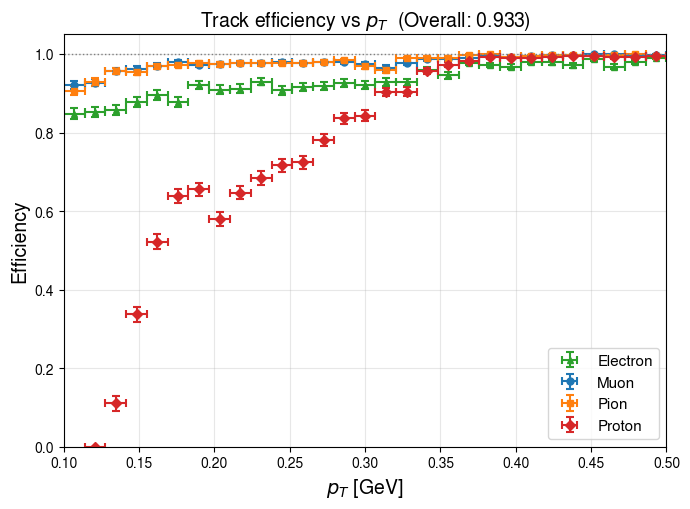

In [20]:
from low_pt_custom_utils.track_evaluation_utils import SPECIES_COLORS, SPECIES_MARKERS

# ── Build particles DataFrame (one row per particle) ─────────────────────────
particles_df = parts.copy()
particles_df['is_reconstructed'] = particles_df.groupby(
    ['event_id', 'particle_id'])['is_reconstructed'].transform('any')
particles_df = particles_df.drop_duplicates(['event_id', 'particle_id'])

pt_bins = np.linspace(0.1, 0.5, 30)
xc = (pt_bins[1:] + pt_bins[:-1]) / 2
xe = (pt_bins[1:] - pt_bins[:-1]) / 2

# ── Per-species efficiency vs pT ──────────────────────────────────────────────
species_list = sorted(particles_df['particle_type'].dropna().unique()) \
               if 'particle_type' in particles_df.columns else ['All']

fig, ax = plt.subplots(figsize=(7, 5.2))

for species in species_list:
    mask = (particles_df['particle_type'] == species).values \
           if species != 'All' else np.ones(len(particles_df), dtype=bool)

    rec  = particles_df['is_reconstructable'].values & mask
    rcd  = particles_df['is_reconstructable'].values & particles_df['is_reconstructed'].values & mask
    pt   = particles_df['pt'].values

    den, _ = np.histogram(pt[rec], bins=pt_bins)
    num, _ = np.histogram(pt[rcd], bins=pt_bins)

    with np.errstate(divide='ignore', invalid='ignore'):
        eff_pt = np.where(den > 0, num / den, np.nan)
        err_pt = np.where(den > 0, np.sqrt(eff_pt * (1 - eff_pt) / den), 0)

    ax.errorbar(xc, eff_pt, xerr=xe, yerr=err_pt,
                fmt=SPECIES_MARKERS.get(species, 'o'),
                color=SPECIES_COLORS.get(species, 'black'),
                capsize=3, capthick=1.5, markersize=5,
                label=species)

ax.axhline(1.0, color='gray', linestyle=':', lw=1)
ax.set_xlabel('$p_T$ [GeV]', fontsize=14)
ax.set_ylabel('Efficiency', fontsize=14)
ax.set_title(
    f'Track efficiency vs $p_T$  (Overall: {eff_val:.3f})', fontsize=14,
)
ax.set_ylim(0, 1.05)
ax.set_xlim(0.1, 0.5)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
fig.tight_layout()

out_path = PIPELINE_ROOT / 'data' / 'visuals' / 'efficiency_vs_pt_gnn_segment_matching.pdf'
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, format='pdf', bbox_inches='tight')
print(f'Saved: {out_path}')

plt.show()

Saved: /data/alice/bkuipers/low_pt_gnn_pipeline/data/visuals/fake_rate_vs_nhits_gnn_segment_matching.pdf


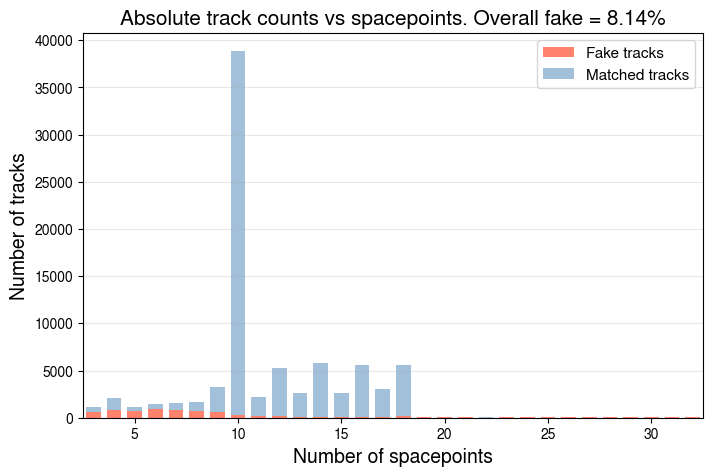

In [21]:
# ── Fake rate & absolute fake count vs number of spacepoints ─────────────────

tracks_unique = trks.drop_duplicates(['event_id', 'track_id'])

max_hits = int(tracks_unique['n_reco_hits'].quantile(0.995))
hit_bins = np.arange(eval_config['min_track_length'], max_hits + 2) - 0.5
xc_h = (hit_bins[1:] + hit_bins[:-1]) / 2

den_h, _ = np.histogram(tracks_unique['n_reco_hits'], bins=hit_bins)
num_h, _ = np.histogram(tracks_unique.loc[~tracks_unique['is_matched'], 'n_reco_hits'],
                        bins=hit_bins)

with np.errstate(divide='ignore', invalid='ignore'):
    fr_h  = np.where(den_h > 0, num_h / den_h, np.nan)
    err_h = np.where(den_h > 0, np.sqrt(fr_h * (1 - fr_h) / den_h), 0)

fig, ax = plt.subplots(figsize=(8, 5))

# ── Left: absolute number of fakes ───────────────────────────────────────────
ax.bar(xc_h, num_h, width=0.7, color='tomato', alpha=0.8, label='Fake tracks')
ax.bar(xc_h, den_h - num_h, width=0.7, bottom=num_h,
       color='steelblue', alpha=0.5, label='Matched tracks')
ax.set_xlabel('Number of spacepoints', fontsize=14)
ax.set_ylabel('Number of tracks', fontsize=14)
ax.set_title(f'Absolute track counts vs spacepoints. Overall fake = {frate_val*100:.2f}%', fontsize=15)
ax.set_xlim(hit_bins[0], hit_bins[-1])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# ── Right: fake rate ──────────────────────────────────────────────────────────
# ax = axes[1]
# ax.errorbar(xc_h, fr_h, yerr=err_h,
#             fmt='o-', color='tomato', capsize=3, capthick=1.5, markersize=5, lw=1.8,
#             label='Fake rate')

# ax.set_xlabel('Number of spacepoints', fontsize=14)
# ax.set_ylabel('Fake rate', fontsize=14)
# ax.set_ylim(0, 1.0)
# ax.set_xlim(hit_bins[0], hit_bins[-1])
# ax.set_title('Fake rate vs spacepoints', fontsize=13)
# ax.legend(fontsize=11)
# ax.grid(True, alpha=0.3)

# fig.suptitle(
#     f'GNN segment matching — boundary={BOUNDARY:.3f} — '
#     f'overall fake={frate_val*100:.2f}%  ({n_t - n_m}/{n_t} tracks)',
#     fontsize=12,
# )
# fig.tight_layout()

out_path = PIPELINE_ROOT / 'data' / 'visuals' / 'fake_rate_vs_nhits_gnn_segment_matching.pdf'
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, format='pdf', bbox_inches='tight')
print(f'Saved: {out_path}')

plt.show()

## Part 4.5 Direct matching ##

In [22]:
# # ── Part 4.5 — Direct cosine threshold matching (transitive / CC-based) ──────
# import scipy.sparse as sps
# from scipy.sparse.csgraph import connected_components as scipy_cc
# from collections import defaultdict

# BOUNDARY_DIRECT = 0.85   # same threshold, or tune independently

# all_dfs_direct = []

# for path in tqdm(event_paths, desc='Evaluating (direct match)'):
#     graph = torch.load(path, map_location='cpu', weights_only=False)

#     segs     = extract_segments_from_cc(graph, SCORE_CUT)
#     complete = [s for s in segs if s.outer_r >= OUTER_R_THRESHOLD]
#     to_match = [s for s in segs if s.outer_r < OUTER_R_THRESHOLD]

#     matched_tracks, unmatched = [], []

#     if len(to_match) >= 2:
#         seg_graphs = [segment_to_pyg(s, graph, node_scales=node_scales) for s in to_match]
#         batch      = Batch.from_data_list(seg_graphs).to(device)
#         with torch.no_grad():
#             embs = model(batch.x, batch.edge_index, batch.batch)
#         embs_np = np.array(embs.detach().cpu().tolist(), dtype=np.float32)
#         sim = embs_np @ embs_np.T

#         n = len(to_match)


#         #print(f"type(sim)={type(sim).__name__}  dtype={getattr(sim,'dtype','?')}  type(BOUNDARY_DIRECT)={type(BOUNDARY_DIRECT).__name__}")

#         # Build adjacency: edge wherever sim >= threshold (exclude diagonal)
#         mask = (sim >= BOUNDARY_DIRECT) & ~np.eye(n, dtype=bool)
#         rows, cols = np.where(mask)
#         adj = sps.csr_matrix((np.ones(len(rows)), (rows, cols)), shape=(n, n))

#         # Connected components → transitive groups
#         n_comp, labels = scipy_cc(adj, directed=False)

#         groups = defaultdict(list)
#         for seg_idx, comp_id in enumerate(labels):
#             groups[comp_id].append(to_match[seg_idx])

#         for segs_in_group in groups.values():
#             if len(segs_in_group) > 1:
#                 matched_tracks.append(segs_in_group)
#             else:
#                 unmatched.append(segs_in_group[0])

#     unmatched = complete + unmatched

#     hit_t = graph.hit_t.cpu().numpy() if hasattr(graph, 'hit_t') else None
#     graph.hit_track_labels = segments_to_track_labels(
#         matched_tracks, unmatched, graph.hit_x.size(0), hit_t=hit_t
#     )

#     all_dfs_direct.append(safe_evaluate_labelled_graph(
#         graph,
#         sel_conf=eval_config['target_tracks'],
#         matching_fraction=eval_config['matching_fraction'],
#         matching_style=eval_config['matching_style'],
#         min_track_length=eval_config['min_track_length'],
#     ))

# eval_df_direct = pd.concat(all_dfs_direct, ignore_index=True)

# parts = eval_df_direct[eval_df_direct['is_reconstructable']]
# reco  = parts[parts['is_reconstructed'] & parts['is_matchable']]
# trks  = eval_df_direct[eval_df_direct['is_matchable']]
# mtchd = trks[trks['is_matched']]

# n_p = len(parts.drop_duplicates(['event_id', 'particle_id']))
# n_r = len(reco.drop_duplicates(['event_id', 'particle_id']))
# n_t = len(trks.drop_duplicates(['event_id', 'track_id']))
# n_m = len(mtchd.drop_duplicates(['event_id', 'track_id']))

# print(f"Boundary  = {BOUNDARY_DIRECT:.4f}")
# print(f"  Efficiency:   {n_r/n_p*100:.1f}%  ({n_r}/{n_p} particles)")
# print(f"  Fake rate:    {(1-n_m/n_t)*100:.2f}%  ({n_t-n_m}/{n_t} tracks)")

In [23]:
# # ── Part 4.5 plots — efficiency & fake rate for direct cosine matching ────────
# parts_d = eval_df_direct[eval_df_direct['is_reconstructable']]
# reco_d  = parts_d[parts_d['is_reconstructed'] & parts_d['is_matchable']]
# trks_d  = eval_df_direct[eval_df_direct['is_matchable']]
# mtchd_d = trks_d[trks_d['is_matched']]

# n_p_d = len(parts_d.drop_duplicates(['event_id', 'particle_id']))
# n_r_d = len(reco_d.drop_duplicates(['event_id', 'particle_id']))
# n_t_d = len(trks_d.drop_duplicates(['event_id', 'track_id']))
# n_m_d = len(mtchd_d.drop_duplicates(['event_id', 'track_id']))
# eff_d   = n_r_d / n_p_d
# frate_d = 1 - n_m_d / n_t_d

# # Per-particle efficiency DataFrame
# particles_d = parts_d.copy()
# particles_d['is_reconstructed'] = particles_d.groupby(
#     ['event_id', 'particle_id'])['is_reconstructed'].transform('any')
# particles_d = particles_d.drop_duplicates(['event_id', 'particle_id'])

# pt_bins = np.linspace(0.1, 0.5, 30)
# xc = (pt_bins[1:] + pt_bins[:-1]) / 2
# xe = (pt_bins[1:] - pt_bins[:-1]) / 2

# species_list = sorted(particles_d['particle_type'].dropna().unique()) \
#                if 'particle_type' in particles_d.columns else ['All']

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# # ── Left: efficiency vs pT per species ───────────────────────────────────────
# for species in species_list:
#     mask = (particles_d['particle_type'] == species).values
#     rec  = particles_d['is_reconstructable'].values & mask
#     rcd  = rec & particles_d['is_reconstructed'].values
#     pt   = particles_d['pt'].values

#     den, _ = np.histogram(pt[rec], bins=pt_bins)
#     num, _ = np.histogram(pt[rcd], bins=pt_bins)
#     with np.errstate(divide='ignore', invalid='ignore'):
#         eff_pt = np.where(den > 0, num / den, np.nan)
#         err_pt = np.where(den > 0, np.sqrt(eff_pt * (1 - eff_pt) / den), 0)

#     ax1.errorbar(xc, eff_pt, xerr=xe, yerr=err_pt,
#                  fmt=SPECIES_MARKERS.get(species, 'o'),
#                  color=SPECIES_COLORS.get(species, 'black'),
#                  capsize=3, capthick=1.5, markersize=5, label=species)

# ax1.axhline(1.0, color='gray', linestyle=':', lw=1)
# ax1.set_xlabel(r'$p_T$ [GeV]', fontsize=13)
# ax1.set_ylabel('Efficiency', fontsize=13)
# ax1.set_title(f'Efficiency vs $p_T$  (overall: {eff_d:.3f})', fontsize=13)
# ax1.set_ylim(0, 1.05); ax1.set_xlim(0.1, 0.5)
# ax1.legend(fontsize=11); ax1.grid(True, alpha=0.3)

# # ── Right: fake rate vs number of spacepoints ─────────────────────────────────
# tracks_unique_d = trks_d.drop_duplicates(['event_id', 'track_id'])
# frate_val = frate_d

# max_hits = int(tracks_unique_d['n_reco_hits'].quantile(0.995))
# hit_bins = np.arange(eval_config['min_track_length'], max_hits + 2) - 0.5
# xc_h = (hit_bins[1:] + hit_bins[:-1]) / 2

# den_h, _ = np.histogram(tracks_unique_d['n_reco_hits'], bins=hit_bins)
# num_h, _ = np.histogram(tracks_unique_d.loc[~tracks_unique_d['is_matched'], 'n_reco_hits'],
#                         bins=hit_bins)

# with np.errstate(divide='ignore', invalid='ignore'):
#     fr_h  = np.where(den_h > 0, num_h / den_h, np.nan)
#     err_h = np.where(den_h > 0, np.sqrt(fr_h * (1 - fr_h) / den_h), 0)

# ax2.bar(xc_h, num_h, width=0.7, color='tomato', alpha=0.8, label='Fake tracks')
# ax2.bar(xc_h, den_h - num_h, width=0.7, bottom=num_h,
#         color='steelblue', alpha=0.5, label='Matched tracks')
# ax2.set_xlabel('Number of spacepoints', fontsize=13)
# ax2.set_ylabel('Number of tracks', fontsize=13)
# ax2.set_title(f'Absolute track counts vs spacepoints  (fake = {frate_val*100:.2f}%)', fontsize=13)
# ax2.set_xlim(hit_bins[0], hit_bins[-1])
# ax2.legend(fontsize=11)
# ax2.grid(True, alpha=0.3, axis='y')

# fig.suptitle(
#     f'Direct cosine matching  (threshold = {BOUNDARY_DIRECT})  —  '
#     f'eff {eff_d*100:.1f}%  fake {frate_d*100:.2f}%',
#     fontsize=13)
# fig.tight_layout()
# plt.show()

---
## Part 5 — Segments per Particle vs $p_T$

How many CC segments does each particle produce? Low-$p_T$ particles loop in the magnetic field → 2 segments (ingoing + outgoing arc). Higher-$p_T$ particles exit the detector entirely → 1 segment. The transition pT is where looping stops.

In [24]:
from low_pt_custom_utils.track_evaluation_utils import PDG_TO_SPECIES

# ── Collect (pT, species, n_segs) for every reconstructable particle ──────────
seg_records = []

for path in tqdm(event_paths, desc='Counting segments per particle'):
    graph = torch.load(path, map_location='cpu', weights_only=False)

    # particle_id → pT and species
    pid_pt      = {}
    pid_species = {}
    if hasattr(graph, 'track_edges') and hasattr(graph, 'track_particle_pt'):
        edge_pids = graph.hit_particle_id[graph.track_edges[0, :]].numpy()
        for pid, pt_val in zip(edge_pids, graph.track_particle_pt.numpy()):
            if pid > 0 and pid not in pid_pt:
                pid_pt[int(pid)] = float(pt_val)
    if hasattr(graph, 'track_edges') and hasattr(graph, 'track_particle_type'):
        edge_pids = graph.hit_particle_id[graph.track_edges[0, :]].numpy()
        for pid, ptype in zip(edge_pids, graph.track_particle_type.numpy()):
            if pid > 0 and pid not in pid_species:
                pid_species[int(pid)] = PDG_TO_SPECIES.get(int(ptype), 'Other')

    # Count CC segments per particle (ALL segments, including complete tracks)
    pid_count = {}
    for seg in extract_segments_from_cc(graph, SCORE_CUT):
        pid = get_segment_particle_id(seg, graph)
        if pid == 0:
            continue
        pid_count[int(pid)] = pid_count.get(int(pid), 0) + 1

    for pid, n_segs in pid_count.items():
        pt_val = pid_pt.get(pid)
        if pt_val is not None:
            seg_records.append({
                'pt':      pt_val,
                'species': pid_species.get(pid, 'Other'),
                'n_segs':  n_segs,
            })

segs_df = pd.DataFrame(seg_records)
print(f"Particles with segment data: {len(segs_df):,}")
print(segs_df['n_segs'].value_counts().sort_index().to_string())

Counting segments per particle: 100%|██████████| 900/900 [00:30<00:00, 29.32it/s]


Particles with segment data: 83,297
n_segs
1    43833
2    38293
3     1156
4       15


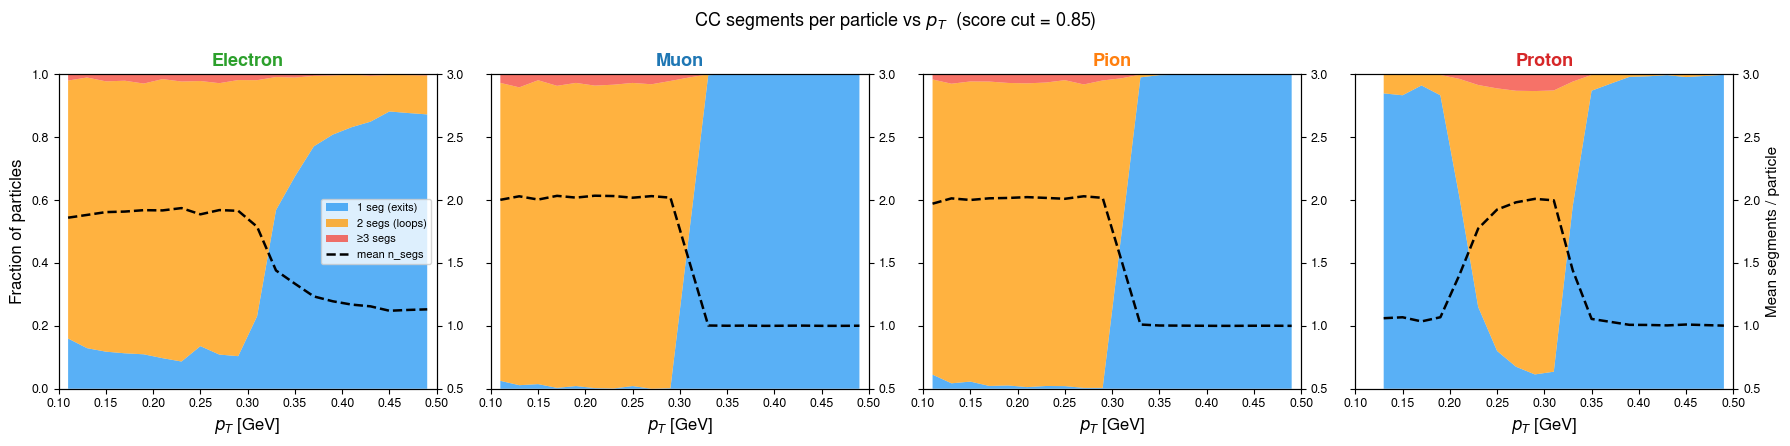

In [25]:
pt_bins    = np.linspace(0.1, 0.5, 21)
xc         = (pt_bins[1:] + pt_bins[:-1]) / 2
xe         = (pt_bins[1:] - pt_bins[:-1]) / 2
seg_colors = {'1': '#2196F3', '2': '#FF9800', '3+': '#F44336'}

species_present = sorted(segs_df['species'].unique())
fig, axes = plt.subplots(1, len(species_present),
                         figsize=(4.5 * len(species_present), 4.5),
                         sharey=True)
if len(species_present) == 1:
    axes = [axes]

for ax, species in zip(axes, species_present):
    sub = segs_df[segs_df['species'] == species]

    f1, f2, f3p, mean_ns = [], [], [], []
    for lo, hi in zip(pt_bins[:-1], pt_bins[1:]):
        b = sub[(sub['pt'] >= lo) & (sub['pt'] < hi)]['n_segs']
        n = len(b)
        if n == 0:
            f1.append(np.nan); f2.append(np.nan)
            f3p.append(np.nan); mean_ns.append(np.nan)
        else:
            f1.append((b == 1).sum() / n)
            f2.append((b == 2).sum() / n)
            f3p.append((b >= 3).sum() / n)
            mean_ns.append(b.mean())

    f1, f2, f3p = np.array(f1), np.array(f2), np.array(f3p)

    # Stacked area: fractions of n=1, 2, ≥3
    valid = ~np.isnan(f1)
    ax.stackplot(xc[valid], f1[valid], f2[valid], f3p[valid],
                 labels=['1 seg (exits)', '2 segs (loops)', '≥3 segs'],
                 colors=[seg_colors['1'], seg_colors['2'], seg_colors['3+']],
                 alpha=0.75)

    # Mean n_segs as a line on secondary axis
    ax2 = ax.twinx()
    ax2.plot(xc[valid], np.array(mean_ns)[valid], 'k--', lw=1.8,
             label='mean n_segs')
    ax2.set_ylim(0.5, 3.0)
    ax2.set_ylabel('Mean segments / particle' if species == species_present[-1] else '',
                   fontsize=11)
    ax2.tick_params(axis='y', labelsize=9)

    color = SPECIES_COLORS.get(species, 'black')
    ax.set_title(species, fontsize=13, color=color, fontweight='bold')
    ax.set_xlabel('$p_T$ [GeV]', fontsize=12)
    ax.set_xlim(0.1, 0.5)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='both', labelsize=9)
    if species == species_present[0]:
        ax.set_ylabel('Fraction of particles', fontsize=12)
    if species == species_present[0]:
        handles1, labels1 = ax.get_legend_handles_labels()
        handles2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(handles1 + handles2, labels1 + labels2, fontsize=8, loc='center right')

fig.suptitle(f'CC segments per particle vs $p_T$  (score cut = {SCORE_CUT})', fontsize=13)
fig.tight_layout()
plt.show()

Saved: /data/alice/bkuipers/low_pt_gnn_pipeline/data/visuals/mean_segments_per_particle_vs_pt.pdf


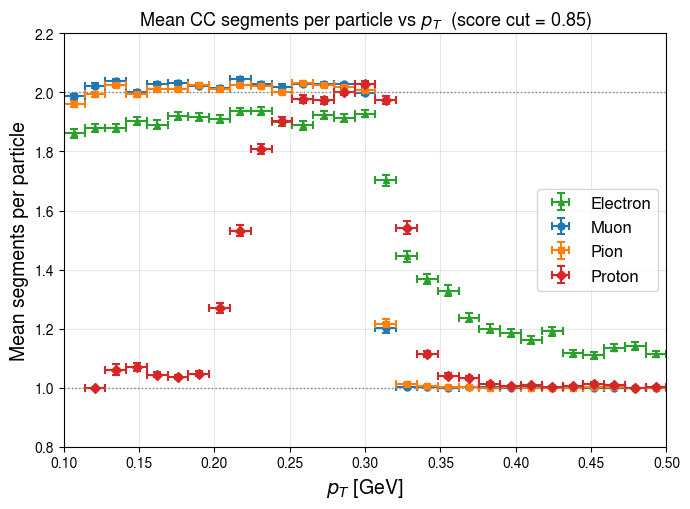

In [26]:
pt_bins = np.linspace(0.1, 0.5, 30)
xc      = (pt_bins[1:] + pt_bins[:-1]) / 2
xe      = (pt_bins[1:] - pt_bins[:-1]) / 2

fig, ax = plt.subplots(figsize=(7, 5.2))

for species in sorted(segs_df['species'].unique()):
    sub = segs_df[segs_df['species'] == species]

    mean_ns, err_ns = [], []
    for lo, hi in zip(pt_bins[:-1], pt_bins[1:]):
        b = sub[(sub['pt'] >= lo) & (sub['pt'] < hi)]['n_segs']
        if len(b) == 0:
            mean_ns.append(np.nan); err_ns.append(0)
        else:
            mean_ns.append(b.mean())
            err_ns.append(b.std() / np.sqrt(len(b)))

    ax.errorbar(xc, mean_ns, xerr=xe, yerr=err_ns,
                fmt=SPECIES_MARKERS.get(species, 'o'),
                color=SPECIES_COLORS.get(species, 'black'),
                capsize=3, capthick=1.5, markersize=5, lw=1.5,
                label=species)

ax.axhline(1.0, color='gray', linestyle=':', lw=1)
ax.axhline(2.0, color='gray', linestyle=':', lw=1)
ax.set_xlabel('$p_T$ [GeV]', fontsize=14)
ax.set_ylabel('Mean segments per particle', fontsize=14)
ax.set_title(f'Mean CC segments per particle vs $p_T$  (score cut = {SCORE_CUT})', fontsize=13)
ax.set_xlim(0.1, 0.5)
ax.set_ylim(0.8, 2.2)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
fig.tight_layout()

out_path = PIPELINE_ROOT / 'data' / 'visuals' / 'mean_segments_per_particle_vs_pt.pdf'
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, format='pdf', bbox_inches='tight')
print(f'Saved: {out_path}')

plt.show()

---
## Part 6 — Ground Truth Particle Distributions

How many reconstructable particles are simulated, and how are they distributed in $p_T$ and $\eta$?


Saved: /data/alice/bkuipers/low_pt_gnn_pipeline/data/visuals/gt_particles_vs_pt.pdf


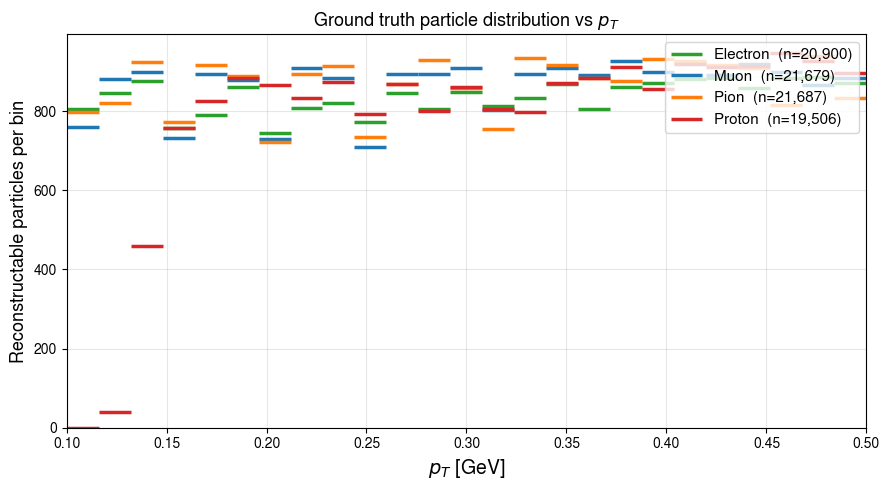

In [27]:

# ── Ground truth particle counts vs pT per species ───────────────────────────
parts_unique = parts.drop_duplicates(['event_id', 'particle_id'])

pt_bins = np.linspace(0.1, 0.5, 26)

species_list = sorted(parts_unique['particle_type'].dropna().unique()) \
               if 'particle_type' in parts_unique.columns else ['All']

fig, ax = plt.subplots(figsize=(9, 5))

for species in species_list:
    mask = (parts_unique['particle_type'] == species).values \
           if species != 'All' else np.ones(len(parts_unique), dtype=bool)
    counts, _ = np.histogram(parts_unique.loc[mask, 'pt'].values, bins=pt_bins)
    color = SPECIES_COLORS.get(species, 'black')
    ax.hlines(counts, pt_bins[:-1], pt_bins[1:],
              colors=color, lw=2.5, label=f'{species}  (n={mask.sum():,})')

ax.set_xlabel('$p_T$ [GeV]', fontsize=14)
ax.set_ylabel('Reconstructable particles per bin', fontsize=13)
ax.set_title('Ground truth particle distribution vs $p_T$', fontsize=13)
ax.set_xlim(0.1, 0.5)
ax.set_ylim(0)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
fig.tight_layout()

out_path = PIPELINE_ROOT / 'data' / 'visuals' / 'gt_particles_vs_pt.pdf'
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, format='pdf', bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

Saved: /data/alice/bkuipers/low_pt_gnn_pipeline/data/visuals/gt_particles_vs_eta.pdf


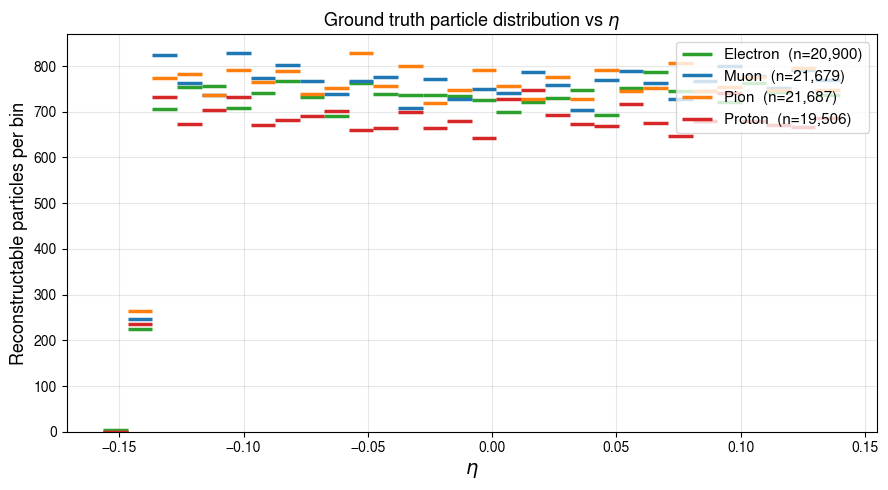

In [28]:
# ── Ground truth particle counts vs eta per species ───────────────────────────
if 'eta' not in parts_unique.columns:
    print("No 'eta' column found in evaluation DataFrame — skipping eta plot.")
else:
    eta_bins = np.linspace(parts_unique['eta'].min(), parts_unique['eta'].max(), 31)

    fig, ax = plt.subplots(figsize=(9, 5))

    for species in species_list:
        mask = (parts_unique['particle_type'] == species).values \
               if species != 'All' else np.ones(len(parts_unique), dtype=bool)
        counts, _ = np.histogram(parts_unique.loc[mask, 'eta'].values, bins=eta_bins)
        color = SPECIES_COLORS.get(species, 'black')
        ax.hlines(counts, eta_bins[:-1], eta_bins[1:],
                  colors=color, lw=2.5, label=f'{species}  (n={mask.sum():,})')

    ax.set_xlabel('$\\eta$', fontsize=14)
    ax.set_ylabel('Reconstructable particles per bin', fontsize=13)
    ax.set_title('Ground truth particle distribution vs $\\eta$', fontsize=13)
    ax.set_ylim(0)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    out_path = PIPELINE_ROOT / 'data' / 'visuals' / 'gt_particles_vs_eta.pdf'
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, format='pdf', bbox_inches='tight')
    print(f'Saved: {out_path}')
    plt.show()



In [29]:
low_pt_protons = eval_df[
    (eval_df['particle_type'] == 'Proton') &
    (eval_df['pt'] < 0.2) &
    (eval_df['is_matchable'])
]
print(low_pt_protons['purity_reco'].describe())
print(low_pt_protons['eff_true'].describe())

count    4705.000000
mean        0.478794
std         0.423142
min         0.016129
25%         0.062500
50%         0.400000
75%         1.000000
max         1.000000
Name: purity_reco, dtype: float64
count    4705.000000
mean        0.679701
std         0.303690
min         0.100000
25%         0.400000
50%         0.750000
75%         1.000000
max         1.000000
Name: eff_true, dtype: float64


## Part 7 — Proton CC Cluster Purity vs $p_T$

For every ground-truth proton that produces **exactly one CC segment**, compute the purity of that segment:

$$\text{purity} = \frac{\text{hits from the proton in the cluster}}{\text{total hits in the cluster}}$$

This happens before any segment matching — it shows whether the GNN is already contaminating proton clusters at the CC stage.

In [30]:
proton_purity_records = []

for path in tqdm(event_paths, desc='Proton cluster purity'):
    graph = torch.load(path, map_location='cpu', weights_only=False)
    hit_pid = graph.hit_particle_id.numpy()

    # pid → pT and species
    pid_pt, pid_species = {}, {}
    if hasattr(graph, 'track_edges') and hasattr(graph, 'track_particle_pt'):
        edge_pids = graph.hit_particle_id[graph.track_edges[0, :]].numpy()
        for pid, pt_val in zip(edge_pids, graph.track_particle_pt.numpy()):
            if pid > 0 and pid not in pid_pt:
                pid_pt[int(pid)] = float(pt_val)
    if hasattr(graph, 'track_edges') and hasattr(graph, 'track_particle_type'):
        edge_pids = graph.hit_particle_id[graph.track_edges[0, :]].numpy()
        for pid, ptype in zip(edge_pids, graph.track_particle_type.numpy()):
            if pid > 0 and pid not in pid_species:
                pid_species[int(pid)] = PDG_TO_SPECIES.get(int(ptype), 'Other')

    # Build hit → segment index map
    segments = extract_segments_from_cc(graph, SCORE_CUT)
    hit_to_seg = {}
    for seg_idx, seg in enumerate(segments):
        for h in seg.hits:
            hit_to_seg[h] = seg_idx

    # For each proton: find which segments contain its hits
    proton_pids = [pid for pid, sp in pid_species.items() if sp == 'Proton']
    for pid in proton_pids:
        pt_val = pid_pt.get(pid)
        if pt_val is None:
            continue

        # All hits belonging to this proton
        proton_hit_indices = np.where(hit_pid == pid)[0]
        if len(proton_hit_indices) == 0:
            continue

        # Which segments contain proton hits, and how many
        seg_hit_count = {}
        for h in proton_hit_indices:
            si = hit_to_seg.get(int(h))
            if si is not None:
                seg_hit_count[si] = seg_hit_count.get(si, 0) + 1

        if len(seg_hit_count) == 0:
            continue

        # Only single-segment protons (by hit presence, not majority vote)
        if len(seg_hit_count) != 1:
            continue

        seg_idx = next(iter(seg_hit_count))
        n_proton_in_seg = seg_hit_count[seg_idx]
        n_total_in_seg  = len(segments[seg_idx].hits)
        purity = n_proton_in_seg / n_total_in_seg

        proton_purity_records.append({
            'pt':      pt_val,
            'purity':  purity,
            'n_total': n_total_in_seg,
        })

purity_df = pd.DataFrame(proton_purity_records)
print(f"Single-segment protons: {len(purity_df):,}")
print(purity_df['purity'].describe())

Proton cluster purity: 100%|██████████| 900/900 [00:22<00:00, 40.89it/s]

Single-segment protons: 13,032
count    13032.000000
mean         0.989391
std          0.073151
min          0.111111
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: purity, dtype: float64


Saved: /data/alice/bkuipers/low_pt_gnn_pipeline/data/visuals/proton_cluster_purity_vs_pt.pdf


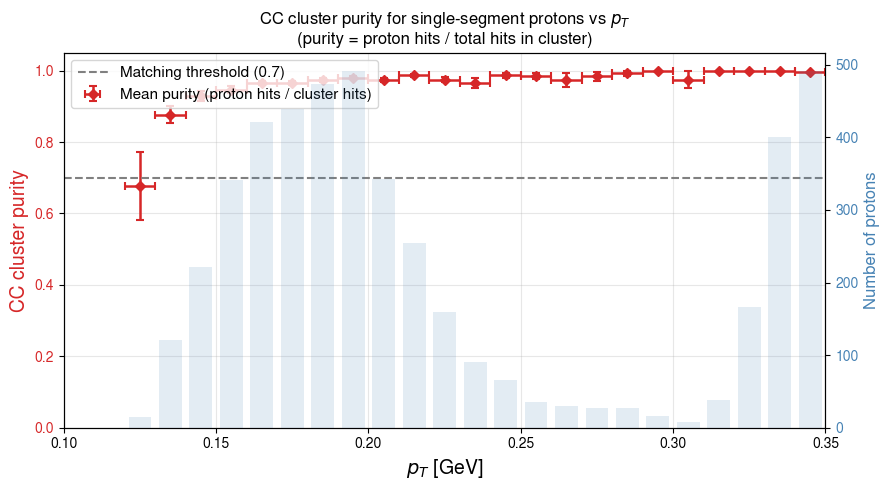

In [31]:
pt_bins = np.linspace(0.1, 0.35, 26)   # single-seg protons mostly below 0.3 GeV
xc = (pt_bins[1:] + pt_bins[:-1]) / 2
xe = (pt_bins[1:] - pt_bins[:-1]) / 2

mean_pur, err_pur, n_bin = [], [], []
for lo, hi in zip(pt_bins[:-1], pt_bins[1:]):
    b = purity_df[(purity_df['pt'] >= lo) & (purity_df['pt'] < hi)]['purity']
    if len(b) == 0:
        mean_pur.append(np.nan); err_pur.append(0); n_bin.append(0)
    else:
        mean_pur.append(b.mean())
        err_pur.append(b.std() / np.sqrt(len(b)))
        n_bin.append(len(b))

mean_pur = np.array(mean_pur)
err_pur  = np.array(err_pur)
n_bin    = np.array(n_bin)

fig, ax1 = plt.subplots(figsize=(9, 5))

proton_color = SPECIES_COLORS.get('Proton', 'red')
ax1.errorbar(xc, mean_pur, xerr=xe, yerr=err_pur,
             fmt=SPECIES_MARKERS.get('Proton', 'o'), color=proton_color,
             capsize=3, capthick=1.5, markersize=5, lw=1.8,
             label='Mean purity (proton hits / cluster hits)')
ax1.axhline(0.7, color='gray', linestyle='--', lw=1.5, label='Matching threshold (0.7)')
ax1.set_xlabel('$p_T$ [GeV]', fontsize=14)
ax1.set_ylabel('CC cluster purity', fontsize=14, color=proton_color)
ax1.tick_params(axis='y', labelcolor=proton_color)
ax1.set_ylim(0, 1.05)
ax1.set_xlim(pt_bins[0], pt_bins[-1])
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.bar(xc, n_bin, width=xe * 1.5, alpha=0.15, color='steelblue')
ax2.set_ylabel('Number of protons', fontsize=12, color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')
ax2.set_ylim(0)

ax1.set_title(
    'CC cluster purity for single-segment protons vs $p_T$\n'
    '(purity = proton hits / total hits in cluster)',
    fontsize=12,
)
fig.tight_layout()

out_path = PIPELINE_ROOT / 'data' / 'visuals' / 'proton_cluster_purity_vs_pt.pdf'
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, format='pdf', bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

In [32]:
proton_purity_records = []

for path in tqdm(event_paths, desc='Proton cluster purity'):
    graph = torch.load(path, map_location='cpu', weights_only=False)
    hit_pid = graph.hit_particle_id.numpy()

    # pid → pT and species
    pid_pt, pid_species = {}, {}
    if hasattr(graph, 'track_edges') and hasattr(graph, 'track_particle_pt'):
        edge_pids = graph.hit_particle_id[graph.track_edges[0, :]].numpy()
        for pid, pt_val in zip(edge_pids, graph.track_particle_pt.numpy()):
            if pid > 0 and pid not in pid_pt:
                pid_pt[int(pid)] = float(pt_val)
    if hasattr(graph, 'track_edges') and hasattr(graph, 'track_particle_type'):
        edge_pids = graph.hit_particle_id[graph.track_edges[0, :]].numpy()
        for pid, ptype in zip(edge_pids, graph.track_particle_type.numpy()):
            if pid > 0 and pid not in pid_species:
                pid_species[int(pid)] = PDG_TO_SPECIES.get(int(ptype), 'Other')

    # Build hit → segment index map
    segments = extract_segments_from_cc(graph, SCORE_CUT)
    hit_to_seg = {}
    for seg_idx, seg in enumerate(segments):
        for h in seg.hits:
            hit_to_seg[h] = seg_idx

    proton_pids = [pid for pid, sp in pid_species.items() if sp == 'Proton']
    for pid in proton_pids:
        pt_val = pid_pt.get(pid)
        if pt_val is None:
            continue

        proton_hit_indices = np.where(hit_pid == pid)[0]
        n_proton_total = len(proton_hit_indices)
        if n_proton_total == 0:
            continue

        # Which segments contain proton hits?
        seg_hit_count = {}
        for h in proton_hit_indices:
            si = hit_to_seg.get(int(h))
            if si is not None:
                seg_hit_count[si] = seg_hit_count.get(si, 0) + 1

        n_segs_present = len(seg_hit_count)
        if n_segs_present == 0:
            continue  # all hits isolated (below score cut)

        # Best segment = the one containing the most proton hits
        best_seg_idx = max(seg_hit_count, key=seg_hit_count.get)
        n_proton_in_best  = seg_hit_count[best_seg_idx]
        n_total_in_best   = len(segments[best_seg_idx].hits)

        purity       = n_proton_in_best / n_total_in_best
        completeness = n_proton_in_best / n_proton_total

        proton_purity_records.append({
            'pt':           pt_val,
            'purity':       purity,
            'completeness': completeness,
            'n_segs':       n_segs_present,
            'n_total':      n_total_in_best,
        })

purity_df = pd.DataFrame(proton_purity_records)
print(f"Protons with ≥1 segment: {len(purity_df):,}")
print(purity_df[['purity', 'completeness']].describe())

Proton cluster purity:  96%|█████████▌| 863/900 [00:28<00:00, 50.60it/s]

Proton cluster purity: 100%|██████████| 900/900 [00:28<00:00, 31.16it/s]

Protons with ≥1 segment: 19,130
             purity  completeness
count  19130.000000  19130.000000
mean       0.988543      0.815974
std        0.072990      0.221979
min        0.111111      0.125000
25%        1.000000      0.562500
50%        1.000000      1.000000
75%        1.000000      1.000000
max        1.000000      1.000000


Saved: /data/alice/bkuipers/low_pt_gnn_pipeline/data/visuals/proton_cluster_purity_vs_pt.pdf


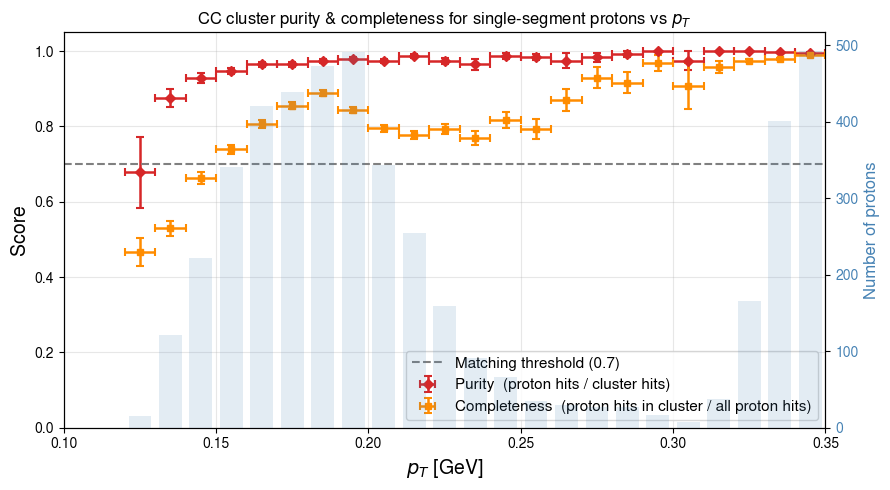

In [33]:
pt_bins = np.linspace(0.1, 0.35, 26)
xc = (pt_bins[1:] + pt_bins[:-1]) / 2
xe = (pt_bins[1:] - pt_bins[:-1]) / 2

# Only single-segment protons for a clean comparison
single_seg = purity_df[purity_df['n_segs'] == 1]

def bin_mean(df, col, pt_bins):
    means, errs, ns = [], [], []
    for lo, hi in zip(pt_bins[:-1], pt_bins[1:]):
        b = df[(df['pt'] >= lo) & (df['pt'] < hi)][col]
        if len(b) == 0:
            means.append(np.nan); errs.append(0); ns.append(0)
        else:
            means.append(b.mean())
            errs.append(b.std() / np.sqrt(len(b)))
            ns.append(len(b))
    return np.array(means), np.array(errs), np.array(ns)

mean_pur,  err_pur,  n_bin = bin_mean(single_seg, 'purity',       pt_bins)
mean_comp, err_comp, _     = bin_mean(single_seg, 'completeness', pt_bins)

proton_color = SPECIES_COLORS.get('Proton', 'red')

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.errorbar(xc, mean_pur,  xerr=xe, yerr=err_pur,
             fmt=SPECIES_MARKERS.get('Proton', 'o'), color=proton_color,
             capsize=3, capthick=1.5, markersize=5, lw=1.8,
             label='Purity  (proton hits / cluster hits)')
ax1.errorbar(xc, mean_comp, xerr=xe, yerr=err_comp,
             fmt='s', color='darkorange',
             capsize=3, capthick=1.5, markersize=5, lw=1.8,
             label='Completeness  (proton hits in cluster / all proton hits)')
ax1.axhline(0.7, color='gray', linestyle='--', lw=1.5, label='Matching threshold (0.7)')

ax1.set_xlabel('$p_T$ [GeV]', fontsize=14)
ax1.set_ylabel('Score', fontsize=14)
ax1.set_ylim(0, 1.05)
ax1.set_xlim(pt_bins[0], pt_bins[-1])
ax1.legend(fontsize=11, loc='lower right')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.bar(xc, n_bin, width=xe * 1.5, alpha=0.15, color='steelblue')
ax2.set_ylabel('Number of protons', fontsize=12, color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')
ax2.set_ylim(0)

ax1.set_title(
    'CC cluster purity & completeness for single-segment protons vs $p_T$',
    fontsize=12,
)
fig.tight_layout()

out_path = PIPELINE_ROOT / 'data' / 'visuals' / 'proton_cluster_purity_vs_pt.pdf'
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, format='pdf', bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

Saved: /data/alice/bkuipers/low_pt_gnn_pipeline/data/visuals/proton_purity_cc_vs_matching.pdf


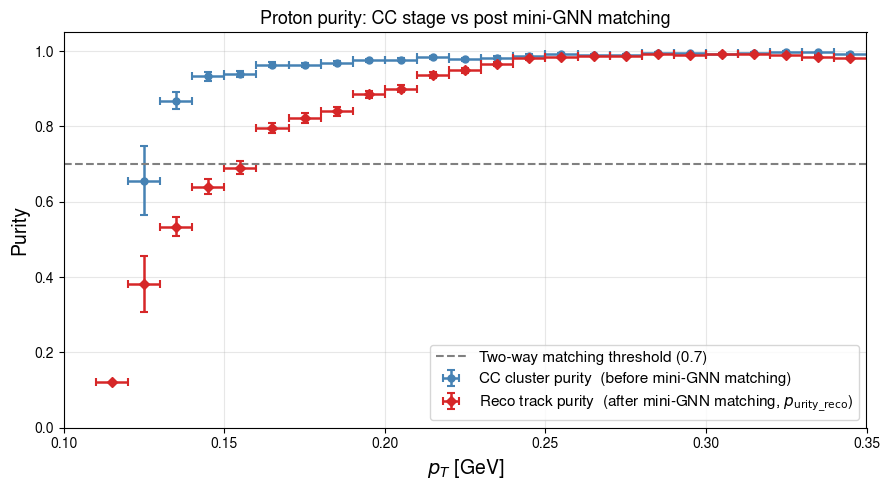


Mean CC purity (low pT < 0.2 GeV)    : 0.909
Mean eval purity_reco (low pT < 0.2) : 0.635


In [34]:
# ── Part 8: CC purity (before matching) vs purity_reco (after matching) ─────
pt_bins = np.linspace(0.1, 0.35, 26)
xc = (pt_bins[1:] + pt_bins[:-1]) / 2
xe = (pt_bins[1:] - pt_bins[:-1]) / 2

# ── Source 1: raw CC cluster purity (Part 7, before any matching) ──────────
# All protons with ≥1 CC segment; use the best segment's purity
mean_cc_pur, err_cc_pur, n_cc = bin_mean(purity_df, 'purity', pt_bins)

# ── Source 2: post-matching purity from eval_df (Part 4) ───────────────────
# All reconstructable protons; take best (highest purity_reco) matched track
eval_protons = eval_df[
    (eval_df['particle_type'] == 'Proton') &
    eval_df['is_reconstructable'] &
    (eval_df['pt'] >= pt_bins[0]) & (eval_df['pt'] < pt_bins[-1])
].copy()

# Keep the best-matched track per particle (highest purity_reco; NaN → 0)
eval_protons['purity_reco'] = eval_protons['purity_reco'].fillna(0.0)
eval_protons_best = (
    eval_protons
    .sort_values('purity_reco', ascending=False)
    .drop_duplicates(['event_id', 'particle_id'], keep='first')
    .rename(columns={'purity_reco': 'purity'})
)
mean_eval_pur, err_eval_pur, n_eval = bin_mean(eval_protons_best, 'purity', pt_bins)

# ── Plot ────────────────────────────────────────────────────────────────────
proton_color = SPECIES_COLORS.get('Proton', 'red')
fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(xc, mean_cc_pur, xerr=xe, yerr=err_cc_pur,
            fmt='o', color='steelblue',
            capsize=3, capthick=1.5, markersize=5, lw=1.8,
            label='CC cluster purity  (before mini-GNN matching)')

ax.errorbar(xc, mean_eval_pur, xerr=xe, yerr=err_eval_pur,
            fmt=SPECIES_MARKERS.get('Proton', 's'), color=proton_color,
            capsize=3, capthick=1.5, markersize=5, lw=1.8,
            label=r'Reco track purity  (after mini-GNN matching, $p_{\rm urity\_reco}$)')

ax.axhline(0.7, color='gray', linestyle='--', lw=1.5, label='Two-way matching threshold (0.7)')

ax.set_xlabel(r'$p_T$ [GeV]', fontsize=14)
ax.set_ylabel('Purity', fontsize=14)
ax.set_ylim(0, 1.05)
ax.set_xlim(pt_bins[0], pt_bins[-1])
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_title('Proton purity: CC stage vs post mini-GNN matching', fontsize=13)

fig.tight_layout()
out_path = PIPELINE_ROOT / 'data' / 'visuals' / 'proton_purity_cc_vs_matching.pdf'
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, format='pdf', bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

print(f'\nMean CC purity (low pT < 0.2 GeV)    : '
      f'{np.nanmean(mean_cc_pur[xc < 0.2]):.3f}')
print(f'Mean eval purity_reco (low pT < 0.2) : '
      f'{np.nanmean(mean_eval_pur[xc < 0.2]):.3f}')

Saved: /data/alice/bkuipers/low_pt_gnn_pipeline/data/visuals/proton_purity_completeness_cc_vs_matching.pdf


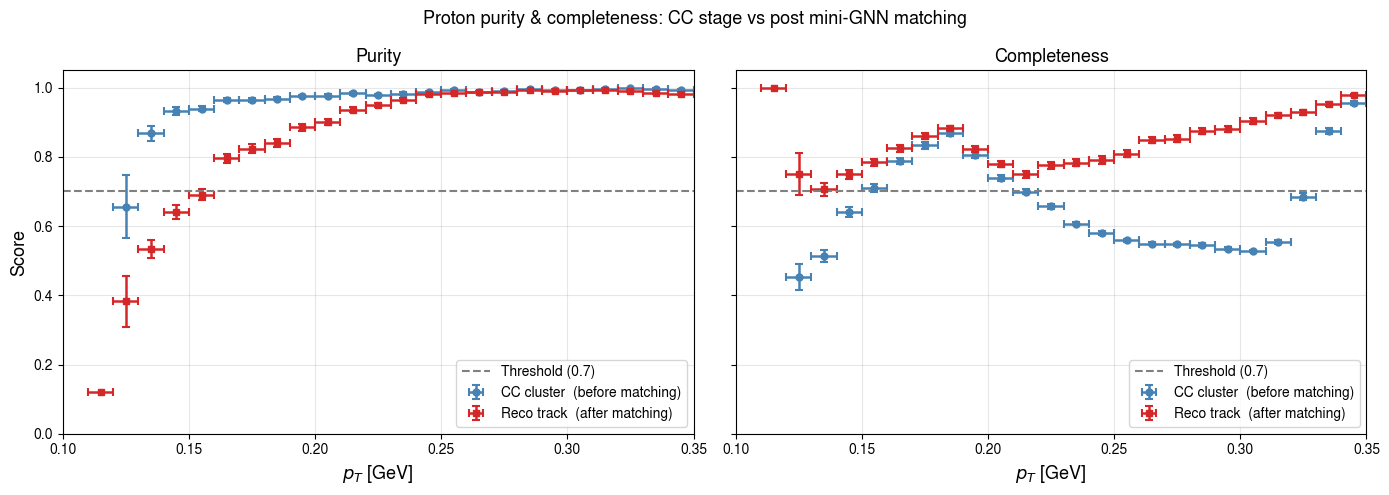


--- low pT < 0.2 GeV ---
CC purity        : 0.909
Eval purity      : 0.635
CC completeness  : 0.701
Eval completeness: 0.820


In [35]:
# ── Part 8: CC purity & completeness (before matching) vs eval_df (after matching) ──
pt_bins = np.linspace(0.1, 0.35, 26)
xc = (pt_bins[1:] + pt_bins[:-1]) / 2
xe = (pt_bins[1:] - pt_bins[:-1]) / 2

# ── Source 1: raw CC metrics (Part 7, before any matching) ─────────────────
mean_cc_pur,  err_cc_pur,  _ = bin_mean(purity_df, 'purity',       pt_bins)
mean_cc_comp, err_cc_comp, _ = bin_mean(purity_df, 'completeness', pt_bins)

# ── Source 2: post-matching metrics from eval_df (Part 4) ──────────────────
eval_protons = eval_df[
    (eval_df['particle_type'] == 'Proton') &
    eval_df['is_reconstructable'] &
    (eval_df['pt'] >= pt_bins[0]) & (eval_df['pt'] < pt_bins[-1])
].copy()

# Fill NaN (unmatched particles) with 0 before taking best-per-particle
eval_protons['purity_reco'] = eval_protons['purity_reco'].fillna(0.0)
eval_protons['eff_true']    = eval_protons['eff_true'].fillna(0.0)

# Best match per particle = highest purity_reco row
eval_protons_best = (
    eval_protons
    .sort_values('purity_reco', ascending=False)
    .drop_duplicates(['event_id', 'particle_id'], keep='first')
    .rename(columns={'purity_reco': 'purity', 'eff_true': 'completeness'})
)
mean_eval_pur,  err_eval_pur,  _ = bin_mean(eval_protons_best, 'purity',       pt_bins)
mean_eval_comp, err_eval_comp, _ = bin_mean(eval_protons_best, 'completeness', pt_bins)

# ── Plot ────────────────────────────────────────────────────────────────────
proton_color = SPECIES_COLORS.get('Proton', 'red')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

kw_cc   = dict(fmt='o', capsize=3, capthick=1.5, markersize=5, lw=1.8, color='steelblue')
kw_eval = dict(fmt='s', capsize=3, capthick=1.5, markersize=5, lw=1.8, color=proton_color)

# Left: purity
ax1.errorbar(xc, mean_cc_pur,   xerr=xe, yerr=err_cc_pur,
             **kw_cc,   label='CC cluster  (before matching)')
ax1.errorbar(xc, mean_eval_pur, xerr=xe, yerr=err_eval_pur,
             **kw_eval, label='Reco track  (after matching)')
ax1.axhline(0.7, color='gray', linestyle='--', lw=1.5, label='Threshold (0.7)')
ax1.set_title('Purity', fontsize=13)
ax1.set_xlabel(r'$p_T$ [GeV]', fontsize=13)
ax1.set_ylabel('Score', fontsize=13)

# Right: completeness
ax2.errorbar(xc, mean_cc_comp,   xerr=xe, yerr=err_cc_comp,
             **kw_cc,   label='CC cluster  (before matching)')
ax2.errorbar(xc, mean_eval_comp, xerr=xe, yerr=err_eval_comp,
             **kw_eval, label='Reco track  (after matching)')
ax2.axhline(0.7, color='gray', linestyle='--', lw=1.5, label='Threshold (0.7)')
ax2.set_title('Completeness', fontsize=13)
ax2.set_xlabel(r'$p_T$ [GeV]', fontsize=13)

for ax in (ax1, ax2):
    ax.set_ylim(0, 1.05)
    ax.set_xlim(pt_bins[0], pt_bins[-1])
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(True, alpha=0.3)

fig.suptitle('Proton purity & completeness: CC stage vs post mini-GNN matching', fontsize=13)
fig.tight_layout()

out_path = PIPELINE_ROOT / 'data' / 'visuals' / 'proton_purity_completeness_cc_vs_matching.pdf'
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, format='pdf', bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

mask_low = xc < 0.2
print(f'\n--- low pT < 0.2 GeV ---')
print(f'CC purity        : {np.nanmean(mean_cc_pur[mask_low]):.3f}')
print(f'Eval purity      : {np.nanmean(mean_eval_pur[mask_low]):.3f}')
print(f'CC completeness  : {np.nanmean(mean_cc_comp[mask_low]):.3f}')
print(f'Eval completeness: {np.nanmean(mean_eval_comp[mask_low]):.3f}')


In [36]:
# ── Collect hit-presence n_clusters per particle (all species) ───────────────
hit_presence_records = []

for path in tqdm(event_paths, desc='Hit-presence cluster count'):
    graph = torch.load(path, map_location='cpu', weights_only=False)
    hit_pid = graph.hit_particle_id.numpy()

    # particle_id → pT and species
    pid_pt, pid_species = {}, {}
    if hasattr(graph, 'track_edges') and hasattr(graph, 'track_particle_pt'):
        edge_pids = graph.hit_particle_id[graph.track_edges[0, :]].numpy()
        for pid, pt_val in zip(edge_pids, graph.track_particle_pt.numpy()):
            if pid > 0 and pid not in pid_pt:
                pid_pt[int(pid)] = float(pt_val)
    if hasattr(graph, 'track_edges') and hasattr(graph, 'track_particle_type'):
        edge_pids = graph.hit_particle_id[graph.track_edges[0, :]].numpy()
        for pid, ptype in zip(edge_pids, graph.track_particle_type.numpy()):
            if pid > 0 and pid not in pid_species:
                pid_species[int(pid)] = PDG_TO_SPECIES.get(int(ptype), 'Other')

    # Build hit → segment index map
    segments = extract_segments_from_cc(graph, SCORE_CUT)
    hit_to_seg = {}
    for seg_idx, seg in enumerate(segments):
        for h in seg.hits:
            hit_to_seg[h] = seg_idx

    # For each truth particle, count distinct segments containing its hits
    for pid, pt_val in pid_pt.items():
        species = pid_species.get(pid, 'Other')
        hit_indices = np.where(hit_pid == pid)[0]
        segs_present = {hit_to_seg[int(h)] for h in hit_indices if int(h) in hit_to_seg}
        hit_presence_records.append({
            'pt':        pt_val,
            'species':   species,
            'n_clusters': len(segs_present),
        })

hp_df = pd.DataFrame(hit_presence_records)
print(f"Particles: {len(hp_df):,}")
print(hp_df.groupby('species')['n_clusters'].describe()[['mean','50%','max']].to_string())




Hit-presence cluster count: 100%|██████████| 900/900 [00:24<00:00, 36.39it/s]


Particles: 84,119
              mean  50%  max
species                     
Electron  1.590294  2.0  4.0
Muon      1.532128  2.0  4.0
Pion      1.533130  2.0  4.0
Proton    1.312430  1.0  5.0


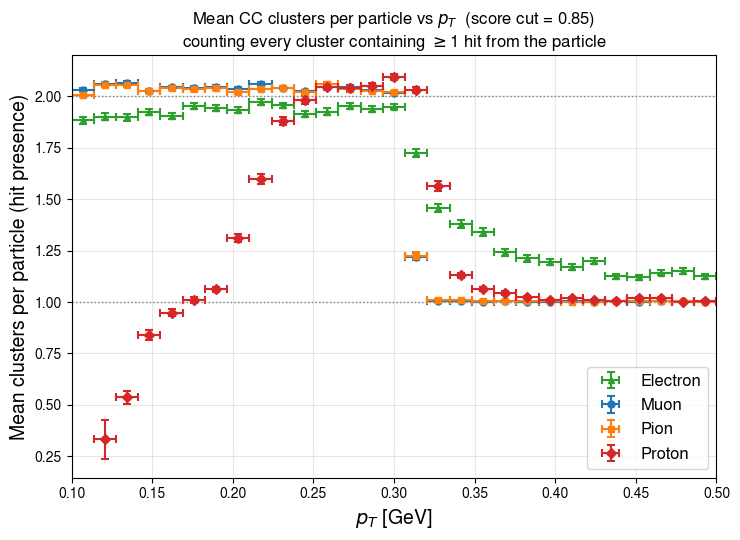

In [37]:
# ── Plot ────────────────────────────────────────────────────────────────────
pt_bins = np.linspace(0.1, 0.5, 30)
xc = (pt_bins[1:] + pt_bins[:-1]) / 2
xe = (pt_bins[1:] - pt_bins[:-1]) / 2

fig, ax = plt.subplots(figsize=(7.5, 5.5))

for species in sorted(hp_df['species'].unique()):
    sub = hp_df[hp_df['species'] == species]
    mean_nc, err_nc = [], []
    for lo, hi in zip(pt_bins[:-1], pt_bins[1:]):
        b = sub[(sub['pt'] >= lo) & (sub['pt'] < hi)]['n_clusters']
        if len(b) == 0:
            mean_nc.append(np.nan); err_nc.append(0)
        else:
            mean_nc.append(b.mean())
            err_nc.append(b.std() / np.sqrt(len(b)))
    ax.errorbar(xc, mean_nc, xerr=xe, yerr=err_nc,
                fmt=SPECIES_MARKERS.get(species, 'o'),
                color=SPECIES_COLORS.get(species, 'black'),
                capsize=3, capthick=1.5, markersize=5, lw=1.5,
                label=species)

ax.axhline(1.0, color='gray', linestyle=':', lw=1)
ax.axhline(2.0, color='gray', linestyle=':', lw=1)
ax.set_xlabel(r'$p_T$ [GeV]', fontsize=14)
ax.set_ylabel('Mean clusters per particle (hit presence)', fontsize=14)
ax.set_title(
    f'Mean CC clusters per particle vs $p_T$  (score cut = {SCORE_CUT})\n'
    r'counting every cluster containing $\geq$1 hit from the particle',
    fontsize=12)
ax.set_xlim(0.1, 0.5)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [38]:
# ── Fake track hit composition by species ────────────────────────────────────
# Fake = matchable track (≥ min_track_length hits) that was NOT matched
fake = eval_df[
    eval_df['is_matchable'] & ~eval_df['is_matched']
][['event_id', 'track_id']].drop_duplicates()

print(f"Fake tracks: {len(fake):,}")

# All eval_df rows for these fake tracks (one row per truth particle sharing hits)
fake_rows = eval_df.merge(fake, on=['event_id', 'track_id']).copy()

# n_shared_hits = purity_reco * n_reco_hits  (purity_reco = n_shared / n_reco_hits)
fake_rows['n_shared'] = fake_rows['purity_reco'].fillna(0.0) * fake_rows['n_reco_hits']

# Total hits across all fake tracks (n_reco_hits is the same for every row of the same track)
total_fake_hits = (
    fake_rows[['event_id', 'track_id', 'n_reco_hits']]
    .drop_duplicates()['n_reco_hits']
    .sum()
)

# Sum shared hits per species
species_counts = (
    fake_rows.groupby('particle_type')['n_shared']
    .sum()
    .sort_values(ascending=False)
)
accounted = species_counts.sum()
noise = total_fake_hits - accounted   # noise / non-reconstructable particles

print(f"Total hits in fake tracks: {total_fake_hits:.0f}\n")
print(f"{'Species':<14} {'Hits':>8}   {'%':>6}")
print("-" * 32)
for sp, n in species_counts.items():
    print(f"  {sp:<12} {n:8.0f}   {100*n/total_fake_hits:5.1f}%")
print(f"  {'Noise/other':<12} {noise:8.0f}   {100*noise/total_fake_hits:5.1f}%")
print("-" * 32)
print(f"  {'TOTAL':<12} {total_fake_hits:8.0f}   100.0%")


Fake tracks: 7,966
Total hits in fake tracks: 85624

Species            Hits        %
--------------------------------
  Proton          34279    40.0%
  Electron        24179    28.2%
  Pion            12496    14.6%
  Muon            12112    14.1%
  Other            2558     3.0%
  Noise/other         0     0.0%
--------------------------------
  TOTAL           85624   100.0%


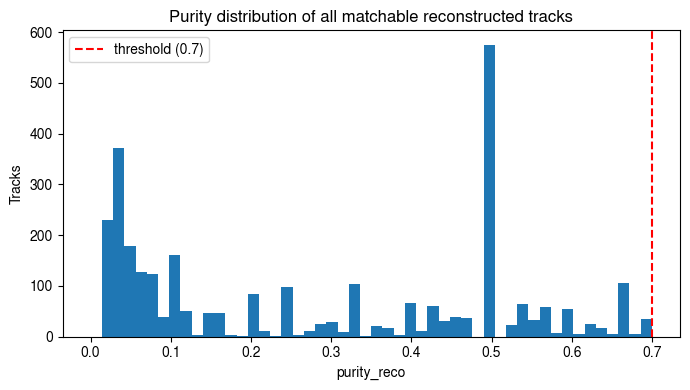

In [39]:
fig, ax = plt.subplots(figsize=(7, 4))
matchable = eval_df[eval_df['is_matchable']].drop_duplicates(['event_id', 'track_id'])
ax.hist(matchable['purity_reco'].fillna(0), bins=50, range=(0, 0.7))
ax.axvline(0.7, color='red', linestyle='--', label='threshold (0.7)')
ax.set_xlabel('purity_reco')
ax.set_ylabel('Tracks')
ax.set_title('Purity distribution of all matchable reconstructed tracks')
ax.legend()
plt.tight_layout()
plt.show()

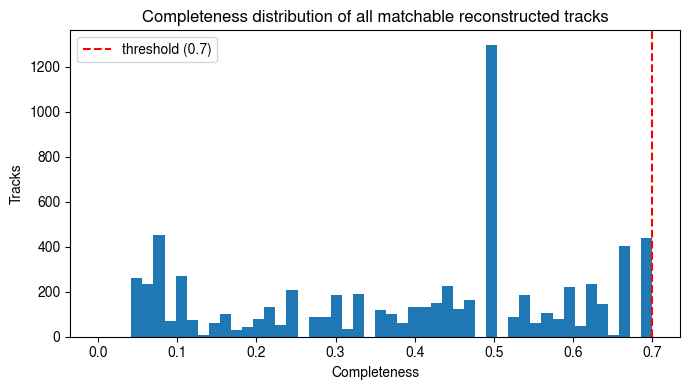

In [40]:
fig, ax = plt.subplots(figsize=(7, 4))
matchable = eval_df[eval_df['is_matchable']].drop_duplicates(['event_id', 'track_id'])
ax.hist(matchable['eff_true'].fillna(0), bins=50, range=(0, 0.7))
ax.axvline(0.7, color='red', linestyle='--', label='threshold (0.7)')
ax.set_xlabel('Completeness')
ax.set_ylabel('Tracks')
ax.set_title('Completeness distribution of all matchable reconstructed tracks')
ax.legend()
plt.tight_layout()
plt.show()


In [41]:

# Among fakes with value < 0.7, what fraction sits exactly at 0.5?
# "Exactly 0.5" = one bin centred on 0.5 with width 1/n_reco_hits (discrete).
# We use a small tolerance window around 0.5.
EPS = 0.005  # ±0.5% — catches the exact 0.5 spike without spillover

fakes_mask = eval_df['is_matchable'] & ~eval_df['is_matched']
# Best-purity candidate per fake (same logic as before)
best_per_fake = (
    eval_df[fakes_mask]
    .sort_values('purity_reco', ascending=False)
    .groupby(['event_id', 'track_id'], sort=False)
    .first()
    .reset_index()
)

for col, label in [('purity_reco', 'Purity'), ('eff_true', 'Completeness')]:
    vals = best_per_fake[col].fillna(0)
    below_thresh = vals[vals < 0.7]
    at_half      = below_thresh[(below_thresh >= 0.5 - EPS) & (below_thresh <= 0.5 + EPS)]
    n_below      = len(below_thresh)
    n_half       = len(at_half)
    print(f"{label}:")
    print(f"  Fakes with {col} < 0.7:          {n_below:,}")
    print(f"  Of those, at exactly ~0.5:        {n_half:,}  ({n_half/n_below:.1%})")
    print()


Purity:
  Fakes with purity_reco < 0.7:          3,426
  Of those, at exactly ~0.5:        618  (18.0%)

Completeness:
  Fakes with eff_true < 0.7:          6,920
  Of those, at exactly ~0.5:        1,406  (20.3%)



Total fake tracks:                7,966
  Failed purity only  (p<0.7, c≥0.7): 1,046  (13.1%)
  Failed completeness only (p≥0.7, c<0.7): 4,540  (57.0%)
  Failed both         (p<0.7, c<0.7): 2,380  (29.9%)


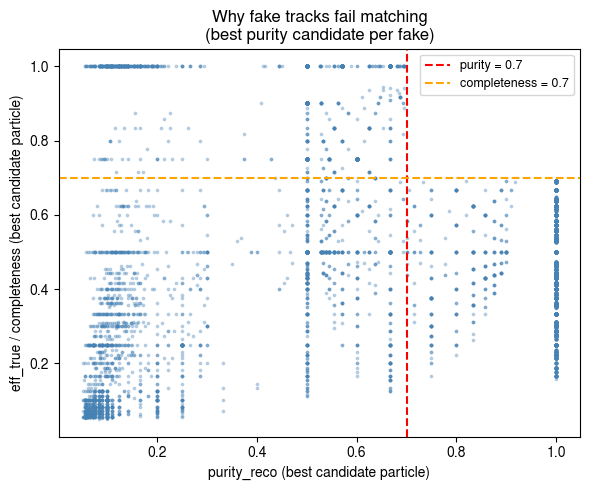

In [42]:

# Two-way matching: purity_reco >= 0.7 AND eff_true >= 0.7 (matching_fraction=0.7, two_way).
# A fake track has NO particle row satisfying both conditions.
# For each fake, take the "best candidate" row = highest purity_reco across truth particles.
THRESH = 0.7

fakes_mask = eval_df['is_matchable'] & ~eval_df['is_matched']
best_per_fake = (
    eval_df[fakes_mask]
    .sort_values('purity_reco', ascending=False)
    .groupby(['event_id', 'track_id'], sort=False)
    .first()
    .reset_index()
)

p  = best_per_fake['purity_reco'].fillna(0)
c  = best_per_fake['eff_true'].fillna(0)

fail_purity_only  = ( (p < THRESH) & (c >= THRESH) ).sum()
fail_comp_only    = ( (p >= THRESH) & (c < THRESH) ).sum()
fail_both         = ( (p < THRESH) & (c < THRESH)  ).sum()
n_fakes           = len(best_per_fake)

print(f"Total fake tracks:                {n_fakes:,}")
print(f"  Failed purity only  (p<0.7, c≥0.7): {fail_purity_only:,}  ({fail_purity_only/n_fakes:.1%})")
print(f"  Failed completeness only (p≥0.7, c<0.7): {fail_comp_only:,}  ({fail_comp_only/n_fakes:.1%})")
print(f"  Failed both         (p<0.7, c<0.7): {fail_both:,}  ({fail_both/n_fakes:.1%})")

# 2D scatter of best-candidate purity vs completeness
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(p, c, s=3, alpha=0.3, color='steelblue')
ax.axvline(THRESH, color='red',   linestyle='--', lw=1.5, label=f'purity = {THRESH}')
ax.axhline(THRESH, color='orange', linestyle='--', lw=1.5, label=f'completeness = {THRESH}')
ax.set_xlabel('purity_reco (best candidate particle)')
ax.set_ylabel('eff_true / completeness (best candidate particle)')
ax.set_title('Why fake tracks fail matching\n(best purity candidate per fake)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


---
## Secondaries

Identify secondary particles — those present in `hit_particle_id` but **not** in `track_edges` (outside the signal selection used when building ground-truth edges). In practice these are very short tracks: all secondaries have only **1 or 2 hits**.

A secondary is called **captured** if ≥ 50% of its hits belong to the same reconstructed track:
- 1-hit: captured if that hit lands in any track
- 2-hit: captured if at least 1 hit is in the same track

The cell re-runs the same track-building loop used in Part 4.

In [43]:
# ── Diagnose particle structure in the first event ───────────────────────────
graph0 = torch.load(event_paths[0], map_location='cpu', weights_only=False)

all_pids    = torch.unique(graph0.hit_particle_id)
all_pids    = all_pids[all_pids > 0]

signal_pids = set()
if hasattr(graph0, 'track_edges'):
    signal_pids = set(graph0.hit_particle_id[graph0.track_edges.reshape(-1)].tolist())
    signal_pids.discard(0)

hit_pid = graph0.hit_particle_id

print(f"Total unique PIDs (excl noise) : {len(all_pids)}")
print(f"PIDs in track_edges (signal)   : {len(signal_pids)}")

# Show n_hits for ALL secondary particles across ALL events
sec_hit_counts = []
for path in event_paths:
    g = torch.load(path, map_location='cpu', weights_only=False)
    pids = torch.unique(g.hit_particle_id)
    pids = pids[pids > 0]
    sig  = set(g.hit_particle_id[g.track_edges.reshape(-1)].tolist()) if hasattr(g, 'track_edges') else set()
    sig.discard(0)
    for pid in pids.tolist():
        if pid not in sig:
            n = int((g.hit_particle_id == pid).sum().item())
            sec_hit_counts.append(n)

sec_hit_counts = sorted(sec_hit_counts)
print(f"\nSecondary particles across all {len(event_paths)} events: {len(sec_hit_counts)}")
if sec_hit_counts:
    from collections import Counter
    cnt = Counter(sec_hit_counts)
    print("  n_hits distribution:")
    for k in sorted(cnt):
        print(f"    {k} hits : {cnt[k]} particles")

del graph0

Total unique PIDs (excl noise) : 93
PIDs in track_edges (signal)   : 91

Secondary particles across all 900 events: 1725
  n_hits distribution:
    1 hits : 875 particles
    2 hits : 850 particles


In [44]:
MIN_SECONDARY_HITS = 1   # all secondaries have 1–2 hits
RECO_THRESHOLD     = 0.5  # ≥50% of hits in one track → "captured"
# For 1-hit: captured if the hit is in any track
# For 2-hit: captured if at least 1 hit is in the same track

secondary_records = []

for path in tqdm(event_paths, desc='Secondaries'):
    graph = torch.load(path, map_location='cpu', weights_only=False)

    # ── Rebuild tracks (same logic as Part 4) ────────────────────────────────
    segs     = extract_segments_from_cc(graph, SCORE_CUT)
    complete = [s for s in segs if s.outer_r >= OUTER_R_THRESHOLD]
    to_match = [s for s in segs if s.outer_r < OUTER_R_THRESHOLD]

    matched_tracks, unmatched = [], complete + to_match

    if len(to_match) >= 2:
        seg_graphs = [segment_to_pyg(s, graph, node_scales=node_scales) for s in to_match]
        batch      = Batch.from_data_list(seg_graphs).to(device)
        with torch.no_grad():
            embs = model(batch.x, batch.edge_index, batch.batch)
        sim = (embs @ embs.T).cpu()

        n     = len(to_match)
        pairs = sorted(
            [(sim[i, j].item(), i, j)
             for i in range(n) for j in range(i + 1, n)
             if sim[i, j].item() >= BOUNDARY],
            reverse=True,
        )
        used = set()
        for s_val, i, j in pairs:
            if i not in used and j not in used:
                matched_tracks.append([to_match[i], to_match[j]])
                used |= {i, j}
        unmatched = complete + [to_match[i] for i in range(n) if i not in used]

    hit_t = graph.hit_t.cpu().numpy() if hasattr(graph, 'hit_t') else None
    graph.hit_track_labels = segments_to_track_labels(
        matched_tracks, unmatched, graph.hit_x.size(0), hit_t=hit_t
    )

    # ── Find secondary PIDs ───────────────────────────────────────────────────
    all_pids = torch.unique(graph.hit_particle_id)
    all_pids = all_pids[all_pids > 0]

    if hasattr(graph, 'track_edges'):
        signal_pids = set(
            graph.hit_particle_id[graph.track_edges.reshape(-1)].tolist()
        )
        signal_pids.discard(0)
    else:
        signal_pids = set()

    hit_pid   = graph.hit_particle_id
    hit_track = graph.hit_track_labels

    for pid in all_pids.tolist():
        if pid in signal_pids:
            continue

        mask   = hit_pid == pid
        n_hits = int(mask.sum().item())
        if n_hits < MIN_SECONDARY_HITS:
            continue

        assigned = hit_track[mask]
        assigned = assigned[assigned >= 0]

        if assigned.numel() == 0:
            secondary_records.append({'n_hits': n_hits, 'is_captured': False, 'purity': 0.0})
            continue

        _, counts  = torch.unique(assigned, return_counts=True)
        purity     = int(counts.max().item()) / n_hits

        secondary_records.append({
            'n_hits':     n_hits,
            'is_captured': purity >= RECO_THRESHOLD,
            'purity':     purity,
        })

sec_df = pd.DataFrame(secondary_records)
n_sec  = len(sec_df)
n_cap  = int(sec_df['is_captured'].sum())
print(f"Secondary particles (>= {MIN_SECONDARY_HITS} hit) across {len(event_paths)} events : {n_sec}")
print(f"  Captured (purity >= {RECO_THRESHOLD:.0%}) : {n_cap}  ({n_cap/max(n_sec,1):.1%})")
print(f"  Not captured                              : {n_sec - n_cap}  ({(n_sec-n_cap)/max(n_sec,1):.1%})")
print()
for nh, grp in sec_df.groupby('n_hits'):
    nc = int(grp['is_captured'].sum())
    print(f"  {nh}-hit secondaries: {len(grp)}  |  captured: {nc} ({nc/len(grp):.1%})")

Secondaries:   6%|▌         | 56/900 [00:11<02:32,  5.53it/s]

Secondaries: 100%|██████████| 900/900 [03:13<00:00,  4.65it/s]

Secondary particles (>= 1 hit) across 900 events : 1725
  Captured (purity >= 50%) : 86  (5.0%)
  Not captured                              : 1639  (95.0%)

  1-hit secondaries: 875  |  captured: 49 (5.6%)
  2-hit secondaries: 850  |  captured: 37 (4.4%)


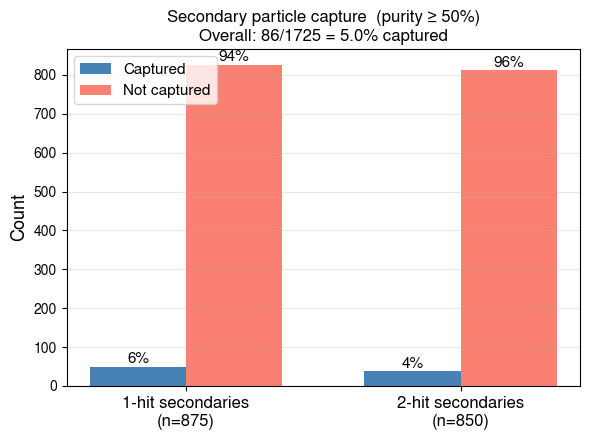

In [45]:
# ── Grouped bar: captured vs not-captured for 1-hit and 2-hit secondaries ────
hit_groups = sorted(sec_df['n_hits'].unique())
captured     = [int(sec_df[sec_df['n_hits'] == nh]['is_captured'].sum())     for nh in hit_groups]
not_captured = [int((~sec_df[sec_df['n_hits'] == nh]['is_captured']).sum())  for nh in hit_groups]
totals       = [c + nc for c, nc in zip(captured, not_captured)]

x    = range(len(hit_groups))
w    = 0.35
fig, ax = plt.subplots(figsize=(6, 4.5))

bars_c  = ax.bar([i - w/2 for i in x], captured,     width=w, color='steelblue', label='Captured')
bars_nc = ax.bar([i + w/2 for i in x], not_captured, width=w, color='salmon',    label='Not captured')

# Fraction labels on top of each bar
for i, (c, nc, tot) in enumerate(zip(captured, not_captured, totals)):
    ax.text(i - w/2, c + 1,  f'{c/tot:.0%}', ha='center', va='bottom', fontsize=11)
    ax.text(i + w/2, nc + 1, f'{nc/tot:.0%}', ha='center', va='bottom', fontsize=11)

ax.set_xticks(list(x))
ax.set_xticklabels([f'{nh}-hit secondaries\n(n={tot})' for nh, tot in zip(hit_groups, totals)], fontsize=12)
ax.set_ylabel('Count', fontsize=13)
ax.set_title(
    f'Secondary particle capture  (purity ≥ {RECO_THRESHOLD:.0%})\n'
    f'Overall: {n_cap}/{n_sec} = {n_cap/max(n_sec,1):.1%} captured',
    fontsize=12,
)
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
plt.show()